In [15]:
<style>
.custom-spacing {
    line-height: 0.5;
}
</style>

### <center>*LAPORAN UJIAN TENGAH SEMESTER*</center>
### <center>*METODE KOMPUTASI II*</center>
#### <center>Disusun Untuk Memenuhi Nilai Ujian Tengah Semester</center>
#### <center>Dosen Pengampu: 
#### <center>Dr. Muhammad Alimuddin Hamzah, M. Eng</center>
#### <center>Dr. Muhammad Taufiq Rafie, MT</center>
#### <center>Muhammad Farid Wajedy, S.Si, M.Si</center>

<div style="text-align:center;">
  <img src="https://www.unhas.ac.id/wp-content/uploads/2022/09/Logo-Resmi-Unhas-1.png" alt="Deskripsi Gambar" style="width:280px;">
</div>

### <center>*DISUSUN OLEH :*</center>
### <center>*KELOMPOK 3B*</center>

#### <center>GANI ABDAN SYAKURAN (H061241053)<center>
#### <center>HERMITA LESTARI           (H061241062)<center>
#### <center>ANDI TRI LESTARI (H061241055)<center>
#### <center>HARDIS HERO PRATAMA (H061241068)<center>
#### <center>WIRNA KHAIRUNNISA ASNAWI (H061241081)<center>
#### <center>DELA SHINTA SUMOMBA (H061241065)<center>
#### <center>MIFTA AL FADIL (H061241048)<center>
#### <center>ABEDNEGO R. PASORONG      (H061241063)<center>
#### <center>SYAUQI ASADUL HAQ (H061241052)<center>
#### <center>MUH. TENRI KAHFI GAMAL P (H061241084)</center>
#### <center>MUH.ARJUNA (H061241074)<center>
#### <center>HAIKAL PRATAMA (H061241058)<center>
#### <center>MACHYTA AHMAD (H061221020)<center>

### <center>*PROGRAM STUDI GEOFISIKA*</center>
### <center>*FAKULTAS MATEMATIKA DAN ILMU PENGETAHUAN ALAM*</center>
#### <center>*UNIVERSITAS HASANUDDIN*</center>
#### <center>*MAKASSAR*</center>
#### <center>*2026*</center>

<hr>

SyntaxError: invalid syntax (2849164672.py, line 1)

In [3]:
%matplotlib inline  
# Perintah khusus di Jupyter Notebook agar grafik langsung muncul di dalam notebook (tidak di jendela terpisah)

from __future__ import print_function  # Mengaktifkan fungsi print seperti di Python 3 (berguna jika pakai Python 2 agar kompatibel)

import numpy  # Mengimpor library NumPy untuk operasi numerik (array, matriks, dll)

import numpy.fft as fft  # Mengimpor modul Fast Fourier Transform (FFT) dari NumPy, lalu disingkat menjadi 'fft'

import matplotlib.pyplot as plt  # Mengimpor modul plotting dari Matplotlib untuk membuat grafik, disingkat 'plt'

# Spectral Methods

## Discrete Fourier Transform

### Definisi

Misalkan $y_n$ dengan $n = 1, \ldots, N$ adalah sederetan $N$ buah data yang nilainya bisa berupa bilangan kompleks.

**Transformasi Fourier Diskrit** (DFT) dari deretan data ini adalah deretan $Y_m$ dengan $m = 1, \ldots, N$ yang dirumuskan sebagai:

$$
Y_m = \sum_{n=1}^N y_n \, e^{-2 \pi i (m - 1)(n - 1) / N}
$$

### Invers Transformasi Fourier Diskrit

Kebalikan dari transformasi ini (invers DFT) dirumuskan sebagai:

$$
y_n = \frac{1}{N} \sum_{m=1}^N Y_m \, e^{2 \pi i (m - 1)(n - 1) / N}
$$

### Kegunaan DFT

Kegunaan DFT sangat luas, mulai dari:

- **Diferensiasi numerik** dengan akurasi tinggi (spektral),
- **Analisis deret waktu**,
- **Penyaringan (filtering)** sinyal,
- **Kuadratur** (menghitung integral numerik).  

Penggunaan langsung rumus-rumus ini akan membutuhkan sekitar $\mathcal{O}(N^2)$ operasi untuk melakukan satu kali transformasi. Namun, jika $N = 2^k$ untuk suatu $k \in \mathbb{Z}^+$, salah satu keajaiban komputasi modern, yaitu fast Fourier transform (FFT), dapat digunakan yang hanya membutuhkan sekitar $\mathcal{O}(N \log N)$ operasi saja. Metode ini dapat diperluas (dengan membagi domain menjadi jumlah titik yang sesuai) tanpa kehilangan kecepatan secara umum. Karena FFT sangat umum digunakan, kebanyakan orang akan tetap menggunakan FFT sebagai pengganti DFT ketika menjelaskan pendekatan-pendekatan yang mereka gunakan..

### Relation to Fourier Analysis

Salah satu sudut pandang yang dapat kita ambil untuk merumuskan metode spektral adalah kita ingin merekonstruksi/mengurai fungsi periodik $y(x)$ dengan panjang gelombang $L$ tertentu, berdasarkan nilai-nilainya pada sekumpulan $N$ titik yang berjarak sama, yaitu
$$
    x_n = \frac{(n-1) L}{N}.
$$

Pertimbangkan koefisien Fourier dari fungsi $y(x)$ kita,
$$
    \hat{y~}_m = \frac{1}{L} \int^L_0 y(x) \exp(-i k(m) x) dx, \quad m = 0, \pm 1, \pm 2, \ldots
$$
di mana bilangan gelombang yang terkait dengan koefisien Fourier ke-$m$ adalah
$$
    k(m) = \frac{2 \pi m}{L}.
$$
Dari koefisien-koefisien ini kita dapat merekonstruksi fungsi $y(x)$ sebagai
$$
    y(x) = \sum^\infty_{m=-\infty} \hat{y~}_m \exp(i k(m) x).
$$

Ingat bahwa kita tahu koefisien $\hat{y~}_m \rightarrow 0$ ketika $m \rightarrow \infty$. Khususnya, jika $y(x) \in C^R$ pada seluruh interval $[0, L]$, maka koefisien Fourier meluruh sebesar $\mathcal{O}(|m|^{-(R + 1)})$.

Untuk menghubungkan koefisien DFT $Y_m$ dengan koefisien Fourier $\hat{y~}_m$, kita dapat mendekati integral di atas dengan menggunakan jumlah Riemann sehingga diperoleh
$$\begin{aligned}
    \hat{y~}_m &\approx \frac{1}{L} \sum^N_{n=1} y(x_n) \exp\left(-i k(m) x_n \right) \Delta x\\
    &= \frac{1}{N} \sum^N_{n=1} y(x_n) \exp\left[-i \frac{2 \pi m}{L} \frac{(n - 1) L}{N} \right] \\
    &= \frac{Y_m}{N}
\end{aligned}$$

Sekarang untuk merekonstruksi aproksimasi secara lengkap, kita ambil $m=1,2,\ldots,N$ dan barisan koefisien Fourier
$$
    M_m = 0, 1, 2, \ldots, N / 2 - 1, - N / 2, \ldots, -1,
$$
dan barisan bilangan gelombang yang bersesuaian
$$
    k_m = k(M_m) = \frac{2 \pi M_m}{L}
$$
sehingga diperoleh
$$\begin{aligned}
    \hat{y~}_M &\approx \frac{Y_m}{N} \\
    y(x) &\approx y_N(x) = \sum^{N/2 - 1}_{M=-N/2} \frac{Y_m}{N} \exp(i k(M) x) = \sum^{N}_{m=1} \frac{Y_m}{N} \exp(i k_m x)
\end{aligned}$$

Untuk contoh-contoh di bawah ini, perhatikan seberapa cepat koefisien FFT menurun untuk berbagai jenis fungsi.
1. Gelombang persegi, $C^0$ dengan koefisien menurun sebesar $\mathcal{O}(|M|^{-1})$. Nilai eksaknya $\hat{y~}_M = -2 i / (\pi M), M$ ganjil.
1. Gelombang gigi gergaji, $C^1$ dengan koefisien menurun sebesar $\mathcal{O}(|M|^{-2})$. Nilai eksaknya $\hat{y~}_M = 2 / (\pi M)^2, M$ ganjil.
1. Fungsi $(1-0.6 \cos(2 \pi x / L))^{-1}$, $C^\infty$ dengan koefisien menurun secara *spektral* (melebihi tingkat aljabar manapun). Nilai eksaknya $\hat{y~}_M = 1.25 \cdot 3^{-|M|}$.

<>:80: SyntaxWarning: invalid escape sequence '\h'
<>:80: SyntaxWarning: invalid escape sequence '\h'
C:\Users\ACER\AppData\Local\Temp\ipykernel_55608\2424841827.py:80: SyntaxWarning: invalid escape sequence '\h'
  axes.set_ylabel("$\hat{y}$ and $Y_N$")


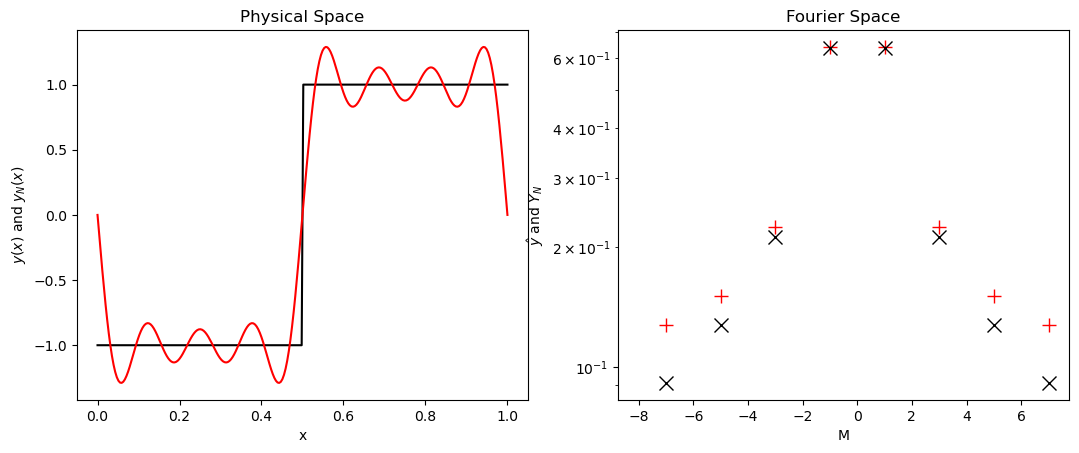

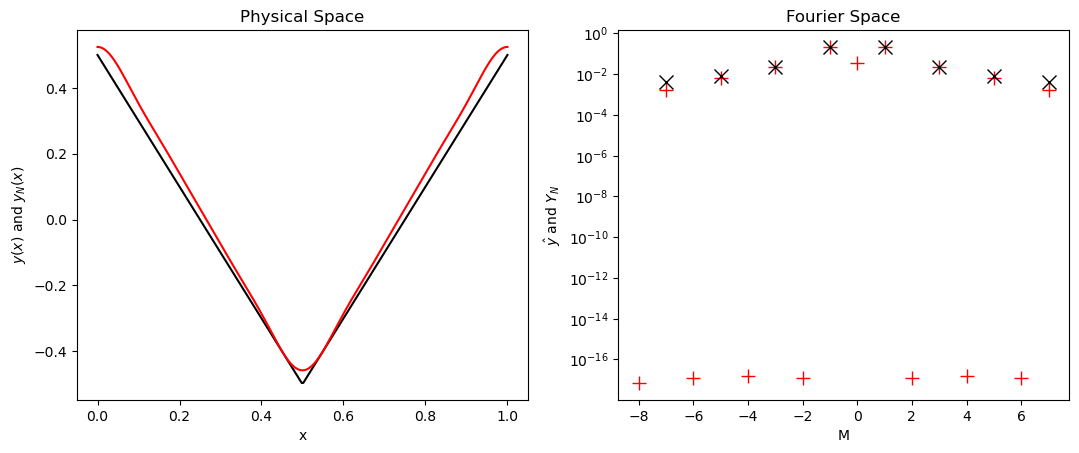

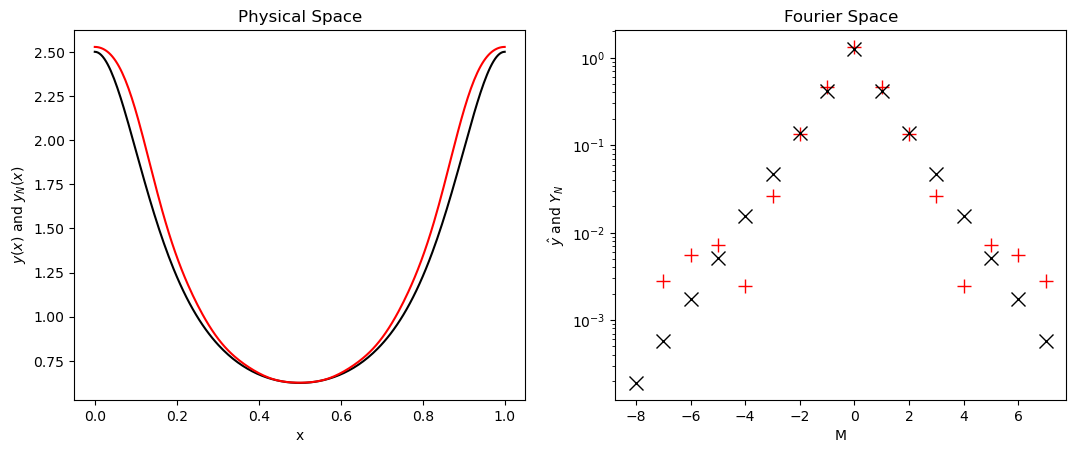

In [4]:
L = 1.0  # Panjang domain (misalnya interval dari 0 sampai 1)

N = 2**4  # Jumlah titik diskrit (2^4 = 16 titik)

x = numpy.linspace(0.0, L, N)  # Membuat N titik merata dari 0 sampai L

delta_x = L / N  # Jarak antar titik (resolusi grid)

x_fine = numpy.linspace(0.0, L, 2**8)  # Grid lebih halus (256 titik) untuk plotting yang lebih smooth

M = fft.fftfreq(N, 1.0 / N)  # Membuat indeks frekuensi Fourier

M_odd = M[numpy.nonzero(numpy.ravel(numpy.mod(M, 2)))]  
# Mengambil hanya indeks frekuensi yang ganjil (digunakan untuk fungsi tertentu)

k = 2.0 * numpy.pi * M / L  
# Mengubah indeks frekuensi M menjadi bilangan gelombang (wave number k)

# Daftar fungsi dalam domain fisik (x)
y = [lambda x: numpy.sign(x - 0.5),                      # Fungsi sign (diskontinu)
     lambda x: numpy.abs(2.0 * x - 1.0) - 0.5,           # Fungsi segitiga
     lambda x: 1.0 / (1.0 - 0.6 * numpy.cos(2.0 * numpy.pi / L * x))]  # Fungsi periodik halus

# Representasi Fourier teoritis dari masing-masing fungsi
y_hat = [lambda M:-2.0j / (numpy.pi * M),                # Fourier untuk fungsi sign
         lambda M:2.0 / (numpy.pi * M)**2,               # Fourier untuk fungsi segitiga
         lambda M:1.25 * 3.0**(-numpy.abs(M))]           # Fourier untuk fungsi halus
    
# Loop untuk setiap fungsi
for (i, y) in enumerate(y):  # i = indeks, y = fungsi

    Y = fft.fft(y(x))  # Menghitung FFT (transformasi Fourier diskrit dari fungsi)

    y_inv = numpy.zeros(x_fine.shape[0])  
    # Menyimpan hasil rekonstruksi fungsi (inverse Fourier)

    for m in range(N):  # Loop semua mode Fourier
        y_inv += ((Y[m] / N) * numpy.exp(1.0j * k[m] * (x_fine - 1.0 / (2.0 * N)))).real
        # Menjumlahkan kontribusi tiap frekuensi untuk membangun kembali fungsi
        # exp(...) = basis gelombang kompleks
        # .real = ambil bagian real saja

    fig = plt.figure()  # Membuat figure baru

    fig.set_figwidth(fig.get_figwidth() * 2)  
    # Memperlebar ukuran gambar (agar 2 subplot muat)

    axes = fig.add_subplot(1, 2, 1)  
    # Subplot pertama (kiri): domain fisik

    axes.plot(x_fine, y(x_fine), 'k')  
    # Plot fungsi asli (warna hitam)

    axes.plot(x_fine, y_inv,'r')  
    # Plot hasil rekonstruksi Fourier (warna merah)

    axes.set_xlabel("x")  # Label sumbu x

    axes.set_ylabel("$y(x)$ and $y_N(x)$")  
    # Label sumbu y (LaTeX format)

    axes.set_title("Physical Space")  
    # Judul grafik kiri

    axes = fig.add_subplot(1, 2, 2)  
    # Subplot kedua (kanan): domain Fourier

    axes.semilogy(M, numpy.abs(Y) / N, '+r', markersize=10)  
    # Plot amplitudo Fourier hasil FFT (skala log, titik merah)

    if i != 2:  
        axes.semilogy(M_odd, numpy.abs(y_hat[i](M_odd)) , 'xk', markersize=10)
        # Untuk fungsi 1 dan 2: bandingkan hanya frekuensi ganjil
    else:
        axes.semilogy(M, numpy.abs((y_hat[i](M))), 'xk', markersize=10)
        # Untuk fungsi ke-3: pakai semua frekuensi

    axes.set_xlabel("M")  # Label sumbu frekuensi

    axes.set_ylabel("$\hat{y}$ and $Y_N$")  
    # Label amplitudo Fourier

    axes.set_title("Fourier Space")  
    # Judul grafik kanan

plt.show()  # Menampilkan semua plot

Secara praktis, dapat dikatakan bahwa semakin halus suatu fungsi, semakin sedikit koefisien Fourier yang kita perlukan untuk dapat mengaproksimasi fungsi $y(x)$ tersebut.

### Sifat-sifat DFT

Misalkan $\mathbf{y}$ adalah vektor yang berisi nilai-nilai titik grid $y_i$, maka DFT dan invers DFT dapat ditulis sebagai operator matriks
$$
    \mathbf{Y} = DFT(\mathbf{y}) = N^{1/2} \mathbf{F} \mathbf{y} \\
    \mathbf{y} = DFT^{-1}(\mathbf{Y}) = N^{1/2} \mathbf{F}^\ast \mathbf{Y}.
$$
Di sini $\mathbf{Y}$ adalah DFT dari $\mathbf{y}$,
$$
    F_{mn} = N^{-1/2} \exp(-2 \pi i (m - 1)(n - 1)),
$$
dan $\mathbf{F}^\ast$ adalah transpose konjugat dari $\mathbf{F}$.

Dari sini kita juga dapat menurunkan *identitas Parseval* untuk transformasi diskrit
$$\begin{aligned}
    \sum^N_{m=1} \frac{|Y^2_m|}{N} &= \frac{\mathbf{Y}^\ast \mathbf{Y}}{N} \\
    &= \mathbf{y}^\ast \mathbf{F}^\ast \mathbf{F} \mathbf{y} \\
    &= \mathbf{y}^\ast \mathbf{y} \\
    &= \sum^N_{n=1} |y^2_n|
\end{aligned}$$
dengan menggunakan fakta bahwa $\mathbf{F}$ adalah matriks uniter (yaitu $\mathbf{F}^\ast \mathbf{F} = \mathbf{F} \mathbf{F}^\ast = \mathbf{I}$).

DFT juga memenuhi teorema konvolusi sehingga
$$
    DFT(w \ast y) = W_m Y_m
$$
dengan
$$
    (w \ast y)_n = \sum^N_{p=1} w_p y_{n-p}
$$
adalah konvolusi dari $w$ dan $y$.

**Teorema** Kehalusan suatu fungsi dan peluruhan koefisien Fouriernya.

Misalkan $u \in L^2(\mathbb R)$ memiliki transformasi Fourier $\hat{u}$, maka
1. Jika $u$ memiliki $p-1$ turunan kontinu dalam $L^2(\mathbb R)$ untuk suatu $p \geq 0$ dan turunan ke-$p$ memiliki variasi terbatas, maka
$$
    \hat{u~}(k) = \mathcal{O}(|k|^{-p-1} ) \quad \text{saat} \quad |k| \rightarrow \infty.
$$
1. Jika $u$ memiliki tak hingga banyak turunan kontinu dalam $L^2(\mathbb R)$ maka
$$
    \hat{u~}(k) = \mathcal{O}(|k|^{-m} ) \quad \text{saat} \quad |k| \rightarrow \infty
$$
untuk setiap $m \geq 0$, ini juga dikenal sebagai konvergensi *spektral*. Kebalikannya juga berlaku.
1. Jika terdapat $a, c > 0$ sehingga $u$ dapat diperluas menjadi fungsi analitik pada pita kompleks $|\Im(z)| < a$ dengan $\| u(\cdot + i y) \| \leq c$ seragam untuk semua $y \in (-a, a)$, di mana $\| u(\cdot + i y) \|$ adalah norma $L^2$ sepanjang garis horizontal $\Im(z) = y$, maka $u_a(k) \in L^2(\mathbb R)$, dengan $u_a(k) = e^{a |k|} \hat{u}(k)$. Kebalikannya juga berlaku.
1. Jika $u$ dapat diperluas menjadi fungsi entire (yaitu analitik di seluruh bidang kompleks) dan terdapat $a > 0$ sehingga $|u(z)| = \mathcal{O}(e^{a|z|})$ saat $z \rightarrow \infty$ untuk semua nilai kompleks $z \in \mathbb C$, maka $\hat{u}$ memiliki support kompak yang termuat dalam $[-a, a]$. Kebalikannya juga berlaku.

### Diferensiasi

Ingat bahwa transformasi Fourier dari suatu turunan mengubah turunan tersebut menjadi ekspresi aljabar:
$$
    \widehat{(u_x)} = i \xi \hat{u~}.
$$
Kita dapat memanfaatkan ini juga dalam kasus diskrit.

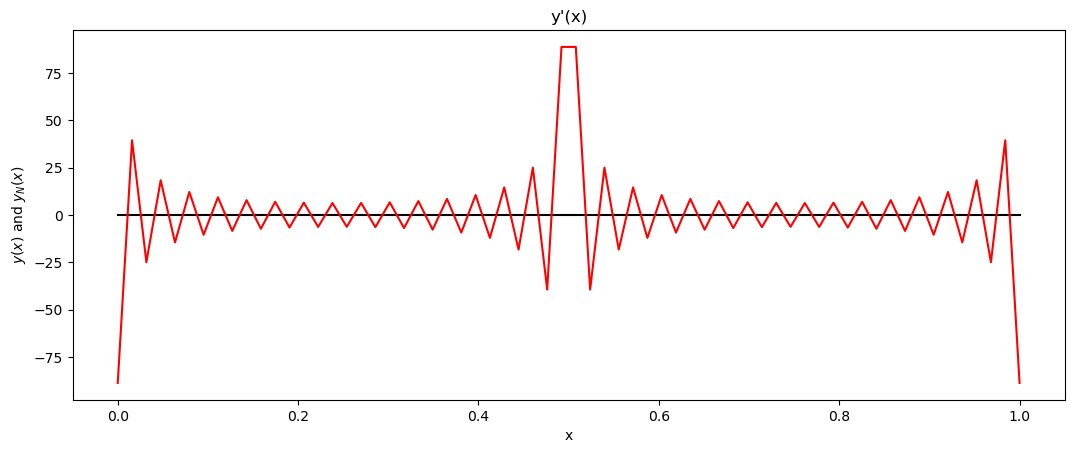

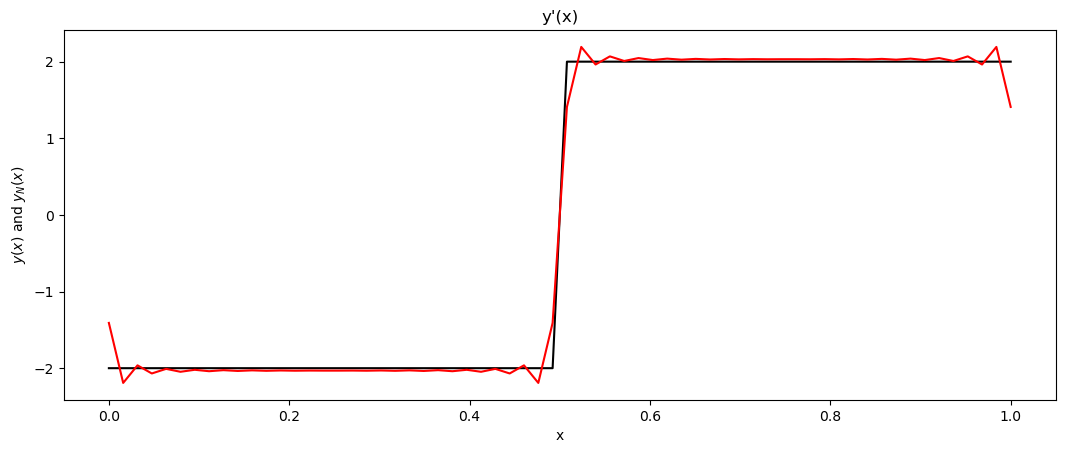

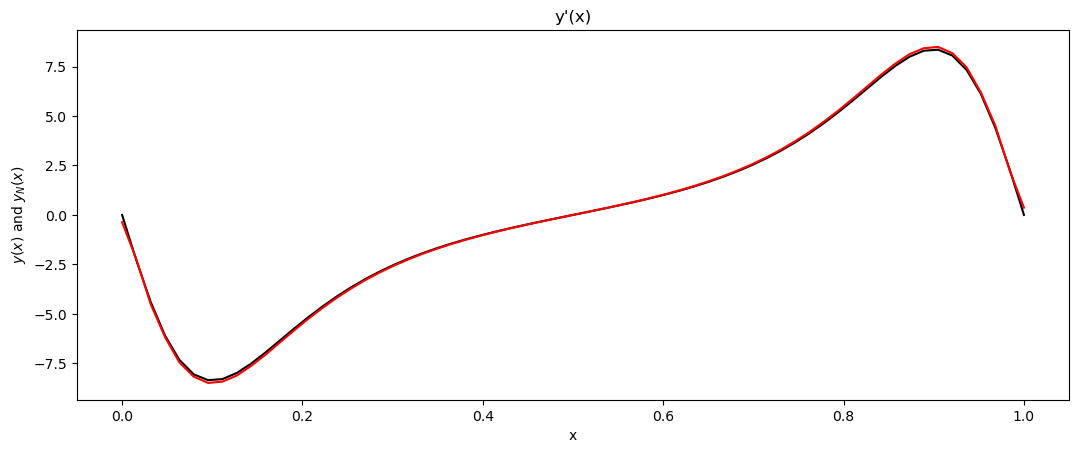

In [5]:
L = 1.0  # Panjang domain (interval dari 0 sampai 1)

N = 2**6  # Jumlah titik diskrit (2^6 = 64 titik, lebih halus dari sebelumnya)

x = numpy.linspace(0.0, L, N)  # Membuat grid titik x dari 0 sampai L

M = fft.fftfreq(N, 1.0 / N)  # Membuat indeks frekuensi Fourier

M_odd = M[numpy.nonzero(numpy.ravel(numpy.mod(M, 2)))]  
# Mengambil frekuensi ganjil (dipakai untuk analisis tertentu, walau tidak digunakan langsung di bawah)

k = 2.0 * numpy.pi * M / L  
# Mengubah indeks frekuensi menjadi bilangan gelombang (k)

# Daftar fungsi yang akan dianalisis
y_funcs = [lambda x: numpy.sign(x - 0.5),  
           # Fungsi sign (diskontinu, loncat di x=0.5)

           lambda x: numpy.abs(2.0 * x - 1.0) - 0.5,  
           # Fungsi segitiga (linear naik turun)

           lambda x: 1.0 / (1.0 - 0.6 * numpy.cos(2.0 * numpy.pi / L * x))]  
           # Fungsi halus periodik

# Turunan analitik (sebenarnya) dari masing-masing fungsi
y_prime_funcs = [lambda x: numpy.zeros(x.shape[0]),  
                 # Turunan fungsi sign = 0 hampir di semua tempat (abaikan titik diskontinu)

                 lambda x: 2.0 * numpy.sign(x - 0.5),  
                 # Turunan fungsi segitiga (nilai konstan +2 atau -2)

                 lambda x: -1.2 * numpy.pi / L * numpy.sin(2.0 * numpy.pi / L * x) / (1.0 - 0.6 * numpy.cos(2.0 * numpy.pi / L * x))**2]
                 # Turunan fungsi halus (dihitung secara analitik)

# Loop untuk setiap fungsi
for (i, y) in enumerate(y_funcs):  # i = indeks, y = fungsi

    Y = fft.fft(y(x))  
    # Menghitung FFT dari fungsi y(x)

    y_prime = fft.ifft(1.0j * k * Y).real  
    # Menghitung turunan menggunakan metode spektral:
    # - di domain Fourier: turunan = i*k * Y
    # - lalu dikembalikan ke domain x dengan inverse FFT
    # - .real = ambil bagian real saja

    fig = plt.figure()  # Membuat figure baru

    fig.set_figwidth(fig.get_figwidth() * 2)  
    # Memperlebar ukuran plot

    axes = fig.add_subplot(1, 1, 1)  
    # Membuat 1 subplot

    axes.plot(x, y_prime_funcs[i](x), 'k')  
    # Plot turunan analitik (warna hitam)

    axes.plot(x, y_prime,'r')  
    # Plot turunan hasil FFT (warna merah)

    axes.set_xlabel("x")  # Label sumbu x

    axes.set_ylabel("$y(x)$ and $y_N(x)$")  
    # Label sumbu y

    axes.set_title("y'(x)")  
    # Judul grafik (turunan fungsi)

plt.show()  # Menampilkan semua grafik

Kita juga dapat menuliskan operasi ini sebagai operasi matriks (dengan asumsi fungsi periodik):
$$\begin{aligned}
    y'(x) \approx N^{-1/2} \mathbf{F}^\ast i \mathbf{K} \mathbf{Y} = N^{-1/2} \mathbf{F}^\ast i \mathbf{K} N^{1/2} \mathbf{F} \mathbf{y} = \mathbf{D} \mathbf{y}
\end{aligned}$$
dengan $D \equiv \mathbf{F}^\ast (i \mathbf{K}) \mathbf{F}$ adalah *matriks diferensiasi pseudospektral Fourier*. Matriks ini riil, rapat (dense), anti-simetris, dan berukuran $N \times N$. Matriks $\mathbf{K} \equiv diag(\mathbf{k})$.

Juga, karena $\mathbf{F}$ bersifat uniter, kita dapat menyusun beberapa turunan hanya dengan menerapkan matriks tersebut beberapa kali untuk mendapatkan turunan ke-$p$.
$$
    D^p = (\mathbf{F}^\ast i \mathbf{K} \mathbf{F})^p = \mathbf{F}^\ast (i \mathbf{K})^p \mathbf{F}
$$

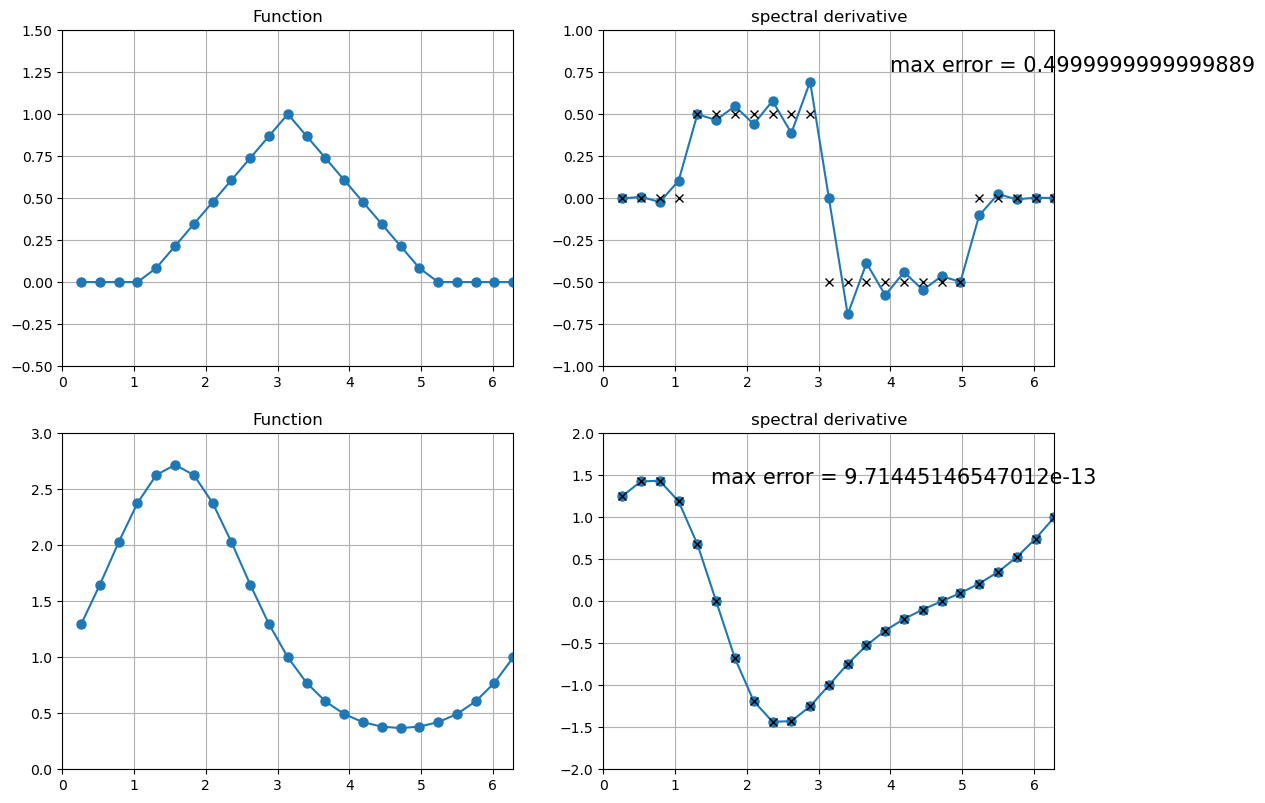

In [11]:
# Example Program 4 from Trefethen - Spectral Methods in MATLAB

import scipy.linalg as linalg  # Import modul linear algebra dari SciPy (untuk membuat matriks Toeplitz)

N = 24  # Jumlah titik grid

delta_x = 2.0 * numpy.pi / N  # Jarak antar titik pada domain [0, 2π]

x = numpy.linspace(delta_x, delta_x * N, N)  
# Membuat titik grid dari Δx sampai 2π (tidak dimulai dari 0, tapi dari Δx)

# =========================
# MEMBUAT DIFFERENTIATION MATRIX (D)
# =========================

column = numpy.empty(N)  
# Menyediakan array kosong untuk kolom pertama matriks D

column[1:] = 0.5*(-1.0)**(numpy.arange(1, N)) * 1.0 / numpy.tan(numpy.arange(1, N) * delta_x / 2.0)
# Mengisi elemen kolom berdasarkan rumus spectral differentiation
# (-1)^k / tan(kΔx/2) adalah inti dari metode spektral (periodik)

column[0] = 0.0  
# Elemen pertama di-set 0 (karena turunan di titik itu mengikuti sifat khusus)

index_array = numpy.empty(N, dtype=int)  
# Array indeks untuk membentuk struktur Toeplitz

index_array[0] = 0  
# Elemen pertama tetap

index_array[1:] = numpy.flipud(numpy.arange(1, N))  
# Membalik urutan indeks (dibutuhkan untuk simetri matriks)

D = linalg.toeplitz(column, column[index_array])  
# Membentuk matriks Toeplitz (matriks dengan diagonal konstan)
# Ini adalah differentiation matrix (operator turunan)

# =========================
# SETUP PLOT
# =========================

fig, axes = plt.subplots(2, 2)  
# Membuat 4 subplot (2x2)

fig.set_figwidth(fig.get_figwidth() * 2)  
# Memperlebar figure

fig.set_figheight(fig.get_figheight() * 2)  
# Mempertinggi figure

# =========================
# CONTOH 1: FUNGSI "HAT"
# =========================

v = numpy.where(1 - numpy.abs(x - numpy.pi) / 2.0 > 0.0, 
                1 - numpy.abs(x - numpy.pi) / 2.0, 
                0.0)
# Fungsi segitiga (hat function), bernilai positif di sekitar π dan nol di luar

v_prime =  numpy.ones(x.shape) * (1 - numpy.abs(x - numpy.pi) / 2.0 > 0.0) * (x < numpy.pi) * 0.5 + \
          -numpy.ones(x.shape) * (1 - numpy.abs(x - numpy.pi) / 2.0 > 0.0) * (x > numpy.pi) * 0.5
# Turunan analitik dari fungsi hat:
# +0.5 di sisi kiri π, -0.5 di sisi kanan π

axes[0, 0].plot(x, v, '.-', markersize=13)  
# Plot fungsi asli

axes[0, 0].set_xlim((0, 2 * numpy.pi))  
# Batas sumbu x

axes[0, 0].set_ylim((-0.5, 1.5))  
# Batas sumbu y

axes[0, 0].set_title("Function")  
# Judul grafik

axes[0, 0].grid(True)  
# Menampilkan grid

axes[0, 1].plot(x, numpy.dot(D, v), '.-', markersize=13)  
# Turunan numerik: D * v (matrix-vector multiplication)

axes[0, 1].plot(x, v_prime, 'kx')  
# Plot turunan analitik (tanda silang hitam)

axes[0, 1].set_xlim((0, 2*numpy.pi))

axes[0, 1].set_ylim((-1, 1))

axes[0, 1].set_title('spectral derivative')

axes[0, 1].grid(True)

error = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.inf)  
# Menghitung error maksimum (norm tak hingga)

axes[0, 1].text(4.0, 0.75, "max error = %s" % error, fontsize=15)  
# Menampilkan nilai error di plot

# =========================
# CONTOH 2: FUNGSI HALUS exp(sin(x))
# =========================

v = numpy.exp(numpy.sin(x))  
# Fungsi halus

v_prime = numpy.cos(x) * v  
# Turunan analitik: d/dx(exp(sin(x))) = cos(x)*exp(sin(x))

axes[1, 0].plot(x, v, '.-', markersize=13)  
# Plot fungsi asli

axes[1, 0].set_xlim((0, 2 * numpy.pi))

axes[1, 0].set_ylim((0.0, 3.0))

axes[1, 0].set_title("Function")

axes[1, 0].grid(True)

axes[1, 1].plot(x, numpy.dot(D, v), '.-', markersize=13)  
# Turunan numerik (spektral)

axes[1, 1].plot(x, v_prime, 'kx')  
# Turunan analitik

axes[1, 1].set_xlim((0, 2*numpy.pi))

axes[1, 1].set_ylim((-2, 2))

axes[1, 1].set_title('spectral derivative')

axes[1, 1].grid(True)

error = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.inf)  
# Error maksimum

axes[1, 1].text(1.5, 1.4, "max error = %s" % error, fontsize=15)  
# Menampilkan error

plt.show()  # Menampilkan semua plot

### Metode Spektral

Kita juga dapat menerapkan pendekatan di atas jika kondisi batas periodik digunakan dan solusi halus diharapkan. Mari kita bahas ini melalui sebuah contoh.

Kita ingin menyelesaikan persamaan adveksi dengan kecepatan variabel
$$
    u_t + c(x) u_x = 0, \quad \Omega = [0, 2 \pi]
$$
dengan kondisi batas periodik dan kondisi awal
$$
    u(x,0) = \exp(-100 (x - 1)^2)
$$
dan kecepatan variabel
$$
    c(x) = 1/5 + \sin^2(x - 1)
$$

Sekarang mari kita konstruksi suatu metode berdasarkan leapfrog dan pendekatan diferensiasi di atas. Perhatikan bahwa dari perspektif metode garis, kita akan memiliki
$$
    \frac{U^{n+1}_j - U^{n+1}_j}{2 \Delta t} = f(U^n) = -c(x_j) (D U^n)_j
$$
di mana di sini kita menggunakan matriks diferensiasi di atas sebagai pengganti beda pusat. Kita juga dapat menggunakan metode (yang lebih efisien) berdasarkan pengetahuan tentang transformasi Fourier dari turunan. Perhatikan bahwa kita menggunakan suatu aproksimasi di sini untuk memulai metode tersebut.

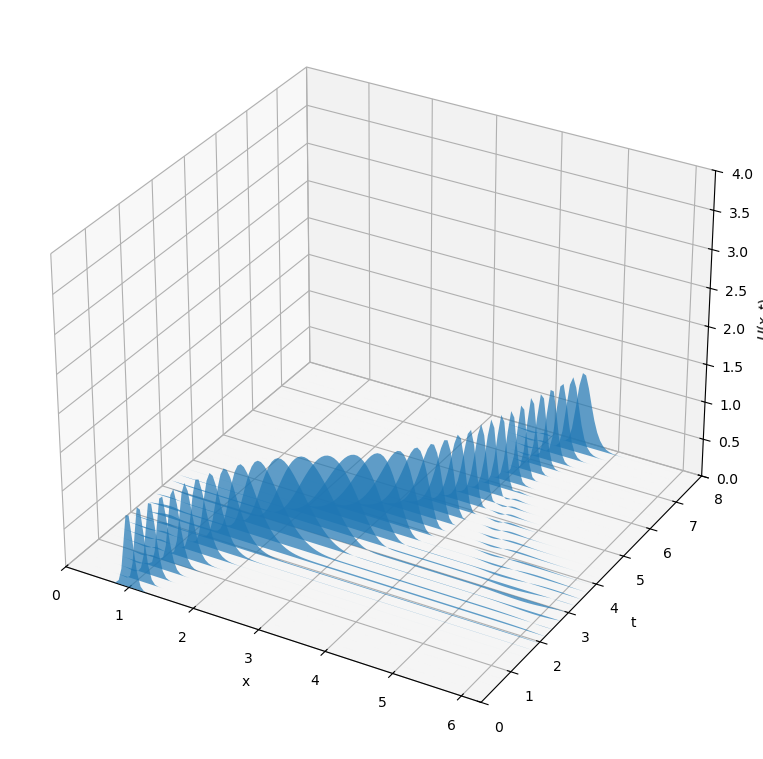

In [12]:
from mpl_toolkits.mplot3d import Axes3D  # Modul untuk plotting 3D di matplotlib
import matplotlib.collections  # Untuk membuat koleksi objek plot (seperti polygon)
import matplotlib.colors  # Untuk mengatur warna dan transparansi

# Compare a pseudo-spectral approach to a finite difference approach
# to the variable coefficient advection problem posed above

# =========================
# MEMBANGUN DOMAIN
# =========================

N = 128  # Jumlah titik grid (resolusi cukup tinggi)

L = 2.0 * numpy.pi  # Panjang domain (0 sampai 2π)

delta_x = L / N  # Jarak antar titik

delta_t = delta_x / 4.0  # Time step (dipilih kecil untuk stabilitas)

x = numpy.linspace(delta_x, delta_x * N, N)  
# Grid spasial (dari Δx sampai 2π)

M = fft.fftfreq(N, 1.0 / N)  
# Frekuensi Fourier

k = 2.0 * numpy.pi * M / L  
# Bilangan gelombang

c = 0.2 + numpy.sin(x - 1.0)**2  
# Kecepatan adveksi (tidak konstan, bergantung x)

# =========================
# MEMBUAT DIFFERENTIATION MATRIX
# =========================

column = numpy.empty(N)  
# Kolom pertama matriks D

column[1:] = 0.5*(-1.0)**(numpy.arange(1, N)) * 1.0 / numpy.tan(numpy.arange(1, N) * delta_x / 2.0)
# Rumus elemen matriks turunan spektral

column[0] = 0.0  
# Elemen pertama

index_array = numpy.empty(N, dtype=int)  
# Array indeks

index_array[0] = 0  

index_array[1:] = numpy.flipud(numpy.arange(1, N))  
# Membalik indeks untuk struktur Toeplitz

D = linalg.toeplitz(column, column[index_array])  
# Matriks turunan (Differentiation Matrix)

# =========================
# KONDISI AWAL
# =========================

U = numpy.exp(-100.0 * (x - 1.0)**2)  
# Profil awal: gelombang Gaussian (tajam di sekitar x=1)

U_old = numpy.exp(-100.0 * (x - 0.2 * delta_t - 1.0)**2)  
# Nilai sebelumnya (untuk metode time stepping, semacam leapfrog)

t_final = 8.0  
# Waktu akhir simulasi

num_steps = int(numpy.ceil(t_final / delta_t))  
# Jumlah langkah waktu

plot_interval = 20  
# Interval untuk menyimpan hasil (tidak semua step disimpan)

t = 0.0  
# Waktu awal

verts = []  
# Menyimpan data untuk plot 3D

t_output = []  
# Menyimpan waktu output

# =========================
# TIME STEPPING
# =========================

for n in range(num_steps):  # Loop waktu

    # Direct discretization of derivative (FFT) -> tidak dipakai (dikomentari)
#     U_hat = fft.fft(U)
#     U_prime_hat = 1.0j * k * U_hat
#     U_prime = fft.ifft(U_prime_hat).real

    # Differentiation matrix
    U_prime = numpy.dot(D, U)  
    # Menghitung turunan spasial menggunakan matriks D

    U_new = U_old - 2.0 * delta_t * c * U_prime  
    # Skema waktu (mirip leapfrog):
    # U_new = U_old - 2Δt * c(x) * dU/dx

    U_old = U  
    # Update nilai sebelumnya

    U = U_new  
    # Update nilai sekarang

    t += delta_t  
    # Update waktu

    if numpy.mod(n, plot_interval) == 0:  
        # Simpan hasil setiap beberapa langkah

        t_output.append(t)  
        # Simpan waktu

        verts.append(list(zip(x, U)))  
        # Simpan pasangan (x, U) untuk plotting 3D

# =========================
# VISUALISASI 3D
# =========================

cc = lambda arg:  matplotlib.colors.colorConverter.to_rgba(arg, alpha=0.6)  
# Fungsi bantu untuk warna transparan (tidak terlalu dipakai langsung)

poly = matplotlib.collections.PolyCollection(verts)  
# Membuat koleksi polygon dari data solusi

poly.set_alpha(0.7)  
# Mengatur transparansi

fig = plt.figure()  
# Membuat figure

fig.set_figwidth(fig.get_figwidth() * 2)  
# Lebar diperbesar

fig.set_figheight(fig.get_figheight() * 2)  
# Tinggi diperbesar

axes = fig.add_subplot(1, 1, 1, projection='3d')  
# Plot 3D

axes.add_collection3d(poly, zs=t_output, zdir='y')  
# Menambahkan data ke plot:
# - x = posisi
# - y = waktu
# - z = nilai U(x,t)

axes.set_xlabel("x")  
# Label sumbu x (ruang)

axes.set_xlim3d(0.0, 2.0 * numpy.pi)

axes.set_ylabel("t")  
# Label sumbu waktu

axes.set_ylim3d(0.0, 8.0)

axes.set_zlabel("$U(x,t)$")  
# Nilai fungsi

axes.set_zlim(0.0, 4)

plt.show()  # Tampilkan plot

## Solver Poisson Berbasis FFT

Kembali ke kuliah tentang metode iteratif untuk masalah Poisson, sempat disebutkan secara singkat bahwa ada cara untuk menyelesaikan masalah Poisson berdasarkan FFT. Di sini kita akan menjelajahi beberapa ide di balik metode yang kuat ini.

Pertimbangkan terlebih dahulu masalah Poisson satu dimensi yang didefinisikan sebagai
$$
    u_{xx} = f(x), \quad \Omega = [0, L]
$$
di mana $f(x)$ periodik bersama dengan kondisi batas periodik.

Pertimbangkan suatu solusi yang merupakan kombinasi linear dari basis Fourier berhingga
$$
    u(x) \approx \frac{1}{N} \sum^N_{n=1} U_n \exp(i k_n x)
$$
dengan
$$
    k_n = \frac{2 \pi}{L} \left\{ \begin{aligned} 
        n - 1, & & 1 \leq n \leq N/2 \\
        n - N - 1, & & N/2 + 1 \leq n \leq N.
    \end{aligned} \right .
$$

Sekarang pertimbangkan $N$ titik kolokasi Fourier
$$
    x_j = \frac{(j-1) L}{N}, \quad j = 1, \ldots, N
$$
dan vektor yang bersesuaian $\mathbf{u} = [u(x_j)]_j$ dan $\mathbf{f} = [f(x_j)]_j$. Dengan mengambil transformasi Fourier dari kedua sisi PDE asli, kita peroleh
$$\begin{aligned}
    (-i k_n)^2 \hat{u~}(k) &= \hat{f}(k) \\
    \hat{u~}(k) &= -\frac{\hat{f~}(k)}{k_n^2}.
\end{aligned}$$
Mengambil invers transformasi dari kedua sisi akan menghasilkan solusi. Dalam kasus diskrit kita memiliki
$$
    \hat{\mathbf{f}~} = \text{DFT}(\mathbf{f}) \\
    U_n = -\frac{\hat{\mathbf{f}~}}{k_n^2} \\
    \mathbf{u} = \text{IDFT}\left(-\frac{\hat{\mathbf{f}~}}{k_n^2}\right).
$$

Satu masalah yang akan kita hadapi adalah $k_n = 0$ untuk $n=1$. Kita dapat mengasumsikan bahwa $F_1 = 0$ sehingga kita setidaknya dapat menangani komponen ini secara unik (secara teknis kita masih akan mendapatkan $0/0$ tetapi ada penanganan untuk kasus ini). Pertanyaannya adalah apakah kita benar-benar harus mengikuti taktik ini.

Kendala bahwa $f_1 = 0$ sebenarnya adalah kondisi untuk keterdefinisian yang baik (well-posedness) dari masalah Poisson pada domain periodik. Komponen ini merepresentasikan nilai rata-rata dari fungsi $f(x)$ dan untungnya dapat dengan mudah dikurangkan dari fungsi tersebut. Pada kenyataannya, sistem tidak tertutup dalam kasus ini dan ada tak hingga banyak solusi yang berbeda berdasarkan nilai rata-ratanya (solusi ditentukan hingga suatu konstanta tambahan). Di sini kita sebenarnya menetapkan bahwa kita mencari solusi di mana konstanta ini sama dengan nol.

C:\Users\ACER\AppData\Local\Temp\ipykernel_55608\3816864323.py:52: ComplexWarning: Casting complex values to real discards the imaginary part
  U_hat[1:] = -F[1:] / k[1:]**2


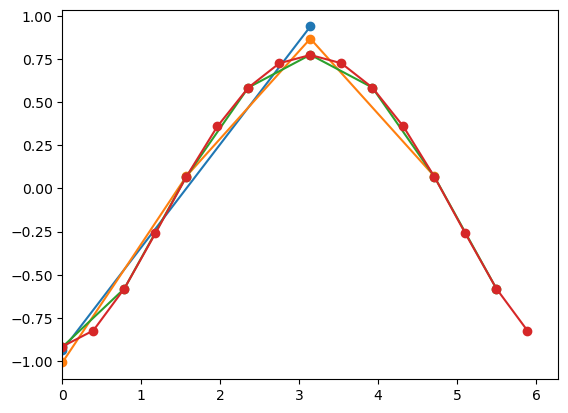

In [13]:
# Fourier spectral method untuk menyelesaikan masalah Poisson

L = 2.0 * numpy.pi  
# Panjang domain (0 sampai 2π)

f = lambda x: 1.0 / (1.0 - 0.6 * numpy.cos(2.0 * numpy.pi * x / L))  
# Fungsi sumber f(x) pada persamaan Poisson

fig, axes = plt.subplots(1, 1)  
# Membuat satu plot

for N in [2, 4, 8, 16]:  
    # Loop untuk berbagai jumlah grid (melihat pengaruh resolusi)

    delta_x = L / N  
    # Jarak antar titik

    delta_t = delta_x / 4.0  
    # Time step (tidak dipakai di sini, sisa dari template sebelumnya)

    x = numpy.linspace(0.0, delta_x * (N - 1), N)  
    # Grid dari 0 sampai L (tanpa titik terakhir L agar periodik)

    # =========================
    # TRANSFORMASI FOURIER
    # =========================

    M = fft.fftfreq(N, 1.0 / N)  
    # Frekuensi Fourier

    k = 2.0 * numpy.pi * M / L  
    # Bilangan gelombang

    F = fft.fft(f(x))  
    # Transformasi Fourier dari f(x)

    if F[0] != 0:  
        F = fft.fft(f(x) - F[0])  
        # Menghilangkan komponen rata-rata (mode nol)
        # Karena persamaan Poisson butuh mean = 0 agar solusi ada

    # =========================
    # MENYELESAIKAN DI DOMAIN FOURIER
    # =========================

    U_hat = numpy.empty(N)  
    # Menyimpan solusi di domain Fourier

    U_hat[0] = 0.0  
    # Mode nol di-set 0 (menghindari pembagian dengan nol)

    U_hat[1:] = -F[1:] / k[1:]**2  
    # Persamaan Poisson di Fourier:
    # -k^2 U_hat = F  →  U_hat = -F / k^2

    # =========================
    # KEMBALI KE DOMAIN FISIK
    # =========================

    U = fft.ifft(U_hat).real  
    # Inverse FFT untuk mendapatkan solusi U(x)
    # .real → ambil bagian real

    # =========================
    # PLOT HASIL
    # =========================

    axes.plot(x, U, 'o-')  
    # Plot solusi untuk setiap N

    axes.set_xlim(0.0, L)  
    # Batas sumbu x

## Metode Spektral Chebyshev

Jadi apa yang terjadi ketika kita tidak berada pada domain periodik? Kita bisa berpikir untuk menggunakan polinomial biasa sebagai pengganti polinomial trigonometri (basis Fourier kita). Namun dari teori interpolasi kita tahu bahwa menggunakan titik-titik yang berjarak sama adalah ide yang buruk.

Sebagai gantinya, kita akan mendistribusikan titik-titik interpolasi sehingga
$$
    x_j = \cos\left(\frac{j \pi}{N} \right), \quad j=0, 1, \ldots, N,
$$
yang disebut *titik Chebyshev* jenis kedua.

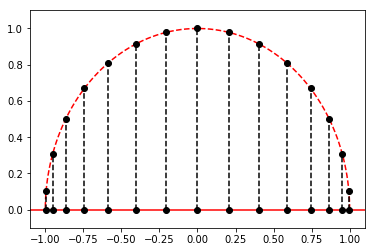

In [ ]:
# Distribution of Chebyshev nodes

x = numpy.linspace(0, numpy.pi, 100)  
# Membuat 100 titik dari 0 sampai π (digunakan untuk menggambar setengah lingkaran)

N = 15  
# Jumlah titik Chebyshev yang ingin ditampilkan

fig = plt.figure()  
# Membuat figure

axes = fig.add_subplot(1, 1, 1)  
# Membuat satu subplot

axes.plot(numpy.cos(x), numpy.sin(x), 'r--')  
# Menggambar setengah lingkaran (parametrik):
# x = cos(θ), y = sin(θ)

axes.plot(numpy.linspace(-1.1, 1.1, 100), numpy.zeros(x.shape), 'r')  
# Menggambar garis horizontal (sumbu x)

# =========================
# MENGHITUNG TITIK CHEBYSHEV
# =========================

for k in range(1, N + 1):  
    # Loop untuk setiap titik Chebyshev

    location = [numpy.cos((2.0 * k - 1.0) * numpy.pi / (2.0 * N)),
                numpy.sin((2.0 * k - 1.0) * numpy.pi / (2.0 * N))]
    # Koordinat titik pada lingkaran:
    # sudut = (2k-1)π / (2N)
    # Ini adalah distribusi Chebyshev pada lingkaran

    axes.plot(location[0], location[1], 'ko')  
    # Plot titik di lingkaran (warna hitam)

    axes.plot(location[0], 0.0, 'ko')  
    # Proyeksi titik ke sumbu x (ini adalah Chebyshev nodes sebenarnya)

    axes.plot([location[0], location[0]], [0.0, location[1]], 'k--')  
    # Garis vertikal dari lingkaran ke sumbu x (visualisasi proyeksi)

# =========================
# PENGATURAN PLOT
# =========================

axes.set_xlim((-1.1, 1.1))  
# Batas sumbu x

axes.set_ylim((-0.1, 1.1))  
# Batas sumbu y

plt.show()  
# Menampilkan plot

Dengan menggunakan basis Lagrange, kita dapat secara langsung melihat perbandingan antara penggunaan titik-titik berjarak sama versus titik-titik Chebyshev.

True


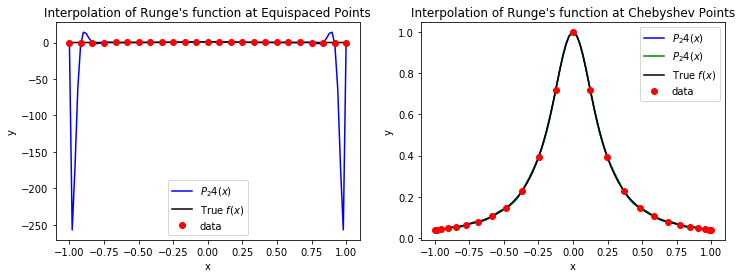

In [ ]:
def f(x):
    return 1.0 / (1.0 + 25.0 * x**2)  
    # Fungsi Runge (contoh klasik yang sering menimbulkan error besar pada interpolasi)

# =========================
# PARAMETER
# =========================

x = numpy.linspace(-1, 1, 100)  
# Grid halus untuk evaluasi dan plotting

num_points = 25  
# Jumlah titik interpolasi

# ============================================================
#  INTERPOLASI DENGAN TITIK MERATA (EQUIDISTANT)
# ============================================================

equidistant_data = numpy.empty((num_points, 2))  
# Menyimpan pasangan (x, f(x))

equidistant_data[:, 0] = numpy.linspace(-1, 1, num_points)  
# Titik x merata dari -1 sampai 1

equidistant_data[:, 1] = f(equidistant_data[:, 0])  
# Nilai fungsi pada titik tersebut

N = equidistant_data.shape[0] - 1  
# Derajat polinomial (N = jumlah titik - 1)

lagrange_basis = numpy.ones((N + 1, x.shape[0]))  
# Matriks basis Lagrange (setiap baris = satu basis)

for i in range(N + 1):  
    for j in range(N + 1):  
        if i != j:  
            lagrange_basis[i, :] *= (x - equidistant_data[j, 0]) / (equidistant_data[i, 0] - equidistant_data[j, 0])
            # Rumus basis Lagrange:
            # L_i(x) = Π (x - x_j)/(x_i - x_j), untuk j ≠ i

# Menghitung polinomial interpolasi penuh
P_lagrange = numpy.zeros(x.shape[0])  

for n in range(N + 1):  
    P_lagrange += lagrange_basis[n, :] * equidistant_data[n, 1]
    # P(x) = Σ L_i(x) * f(x_i)

# ============================================================
#  INTERPOLASI DENGAN TITIK CHEBYSHEV
# ============================================================

chebyshev_data = numpy.empty((num_points, 2))  

chebyshev_data[:, 0] = numpy.cos((2.0 * numpy.arange(1, num_points + 1) - 1.0) * numpy.pi / (2.0 * num_points))  
# Titik Chebyshev (tidak merata, lebih rapat di tepi)

chebyshev_data[:, 1] = f(chebyshev_data[:, 0])  
# Nilai fungsi di titik Chebyshev

# Membuat interpolasi Lagrange lagi (tapi pakai Chebyshev nodes)
lagrange_basis = numpy.ones((N + 1, x.shape[0]))  

for i in range(N + 1):  
    for j in range(N + 1):  
        if i != j:  
            lagrange_basis[i, :] *= (x - chebyshev_data[j, 0]) / (chebyshev_data[i, 0] - chebyshev_data[j, 0])
            # Sama seperti sebelumnya, tapi titiknya berbeda

# Polinomial interpolasi
P_cheby1 = numpy.zeros(x.shape[0])  

for n in range(N + 1):  
    P_cheby1 += lagrange_basis[n, :] * chebyshev_data[n, 1]

# ============================================================
#  FIT LANGSUNG DENGAN POLINOMIAL CHEBYSHEV
# ============================================================

coeff = numpy.polynomial.chebyshev.chebfit(chebyshev_data[:, 0], chebyshev_data[:, 1], N)  
# Menghitung koefisien polinomial Chebyshev secara langsung

P_cheby2 = numpy.polynomial.chebyshev.chebval(x, coeff)  
# Evaluasi polinomial Chebyshev di titik x

# Cek apakah hasil metode Lagrange dan Chebyshev sama
print(numpy.allclose(P_cheby1, P_cheby2))  
# Harus True (dua metode menghasilkan hasil yang sama)

# ============================================================
# PLOT HASIL
# ============================================================

fig = plt.figure()  

fig.set_figwidth(fig.get_figwidth() * 2.0)  
# Memperlebar plot

# ---- Plot 1: Titik Merata ----
axes = fig.add_subplot(1, 2, 1)  

axes.plot(x, P_lagrange, 'b', label="$P_%s(x)$" % N)  
# Polinomial interpolasi

axes.plot(x, f(x), 'k', label="True $f(x)$")  
# Fungsi asli

axes.plot(equidistant_data[:, 0], equidistant_data[:, 1], 'ro', label="data")  
# Titik data

axes.set_title("Interpolation of Runge's function at Equispaced Points")

axes.set_xlabel("x")

axes.set_ylabel("y")

axes.legend(loc=8)

# ---- Plot 2: Chebyshev ----
axes = fig.add_subplot(1, 2, 2)  

axes.plot(x, P_cheby1, 'b', label="$P_%s(x)$" % N)  
# Interpolasi Lagrange dengan Chebyshev nodes

axes.plot(x, P_cheby2, 'g', label="$P_%s(x)$" % N)  
# Interpolasi dengan basis Chebyshev

axes.plot(x, f(x), 'k', label="True $f(x)$")  
# Fungsi asli

axes.plot(chebyshev_data[:, 0], chebyshev_data[:, 1], 'ro', label="data")  
# Titik Chebyshev

axes.set_title("Interpolation of Runge's function at Chebyshev Points")

axes.set_xlabel("x")

axes.set_ylabel("y")

axes.legend(loc=1)

plt.show()  
# Tampilkan plot

Ada dua jenis node Chebyshev yang keduanya akan bekerja sama baiknya sebagai titik interpolasi.

1. Node Chebyshev jenis pertama (akar-akar)
$$
    x_k = \cos \left (\frac{(2 k - 1) \pi}{2 N} \right ) \quad k = 1, \ldots, N
$$
1. Node Chebyshev jenis kedua (titik-titik ekstrim)
$$
    x_k = \cos \left( \frac{k \pi}{N} \right) \quad k = 0, \ldots, N
$$

[ 1.          0.80901699  0.30901699 -0.30901699 -0.80901699 -1.        ]
[ 0.54030231  0.69021008  0.95263298  0.95263298  0.69021008  0.54030231]


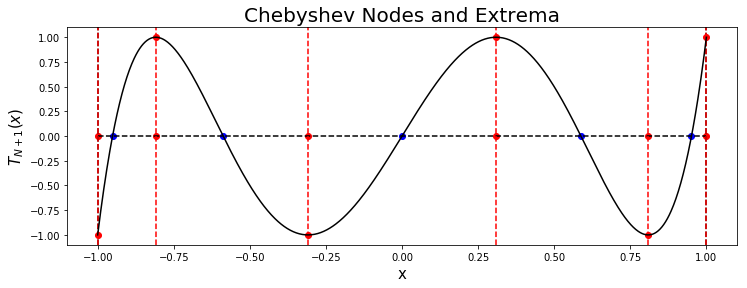

In [ ]:
def cheb_poly(x, N):
    """Compute the *N*th Chebyshev polynomial and evaluate it at *x*"""
    
    T = numpy.empty((3, x.shape[0]))  
    # Menyimpan 3 level polinomial:
    # T[0] = T_{k-2}, T[1] = T_{k-1}, T[2] = T_k

    T[0, :] = numpy.ones(x.shape)  
    # T0(x) = 1

    T[1, :] = x  
    # T1(x) = x

    for k in range(2, N):  
        # Rekurensi Chebyshev:
        # T_k(x) = 2x T_{k-1}(x) - T_{k-2}(x)

        T[2, :] = 2.0 * x * T[1, :] - T[0, :]  
        # Hitung T_k

        T[0, :] = T[1, :]  
        # Geser: T_{k-2} ← T_{k-1}

        T[1, :] = T[2, :]  
        # Geser: T_{k-1} ← T_k
    
    return T[2, :]  
    # Mengembalikan T_N(x)

# =========================
# PARAMETER
# =========================

N = 5  
# Orde polinomial

x_extrema = numpy.cos(numpy.arange(N + 1) * numpy.pi / N)  
# Titik ekstrem (maksimum/minimum) Chebyshev:
# x_k = cos(kπ/N), k=0,...,N

x_nodes = numpy.cos((2.0 * numpy.arange(1, N + 1) - 1.0) / (2.0 * N) * numpy.pi)  
# Titik node Chebyshev (untuk interpolasi):
# x_k = cos((2k-1)π/(2N))

fig = plt.figure()  

fig.set_figwidth(fig.get_figwidth() * 2)  
# Memperlebar plot

axes = fig.add_subplot(1, 1, 1)  
# Membuat subplot

# =========================
# PLOT TITIK
# =========================

axes.plot(x_extrema, numpy.zeros(N+1), 'ro')  
# Plot titik ekstrem (merah)

axes.plot(x_nodes, numpy.zeros(N), 'bo')  
# Plot titik node (biru)

# =========================
# GARIS BANTU
# =========================

axes.plot((-1.0, -1.0), (-1.1, 1.1), 'k--')  
# Garis vertikal di x = -1

axes.plot((1.0, 1.0), (-1.1, 1.1), 'k--')  
# Garis vertikal di x = 1

axes.plot((-1.0, 1.0), (0.0, 0.0), 'k--')  
# Garis horizontal sumbu x

for i in range(x_extrema.shape[0]):  
    # Loop semua titik ekstrem

    axes.plot((x_extrema[i], x_extrema[i]), (-1.1, 1.1), 'r--')  
    # Garis vertikal dari tiap ekstrem

    axes.plot(x_extrema[i], cheb_poly(x_extrema, N + 1)[i], 'ro')  
    # Plot nilai polinomial di titik ekstrem

# =========================
# PRINT DATA
# =========================

print(x_extrema)  
# Menampilkan titik ekstrem

print(numpy.cos(x_extrema))  
# Menampilkan cos(x_extrema) (sekadar eksplorasi nilai)

# =========================
# PLOT POLINOMIAL CHEBYSHEV
# =========================

x_hat = numpy.linspace(-1, 1, 1000)  
# Grid halus untuk plot

axes.plot(x_hat, cheb_poly(x_hat, N + 1), 'k')  
# Plot T_{N+1}(x)

axes.set_xlim((-1.1, 1.1))  

axes.set_ylim((-1.1, 1.1))  

# =========================
# LABEL
# =========================

axes.set_title("Chebyshev Nodes and Extrema", fontsize="20")  

axes.set_xlabel("x", fontsize="15")  

axes.set_ylabel("$T_{N+1}(x)$", fontsize="15")  

plt.show()  
# Tampilkan plot

Sifat menarik lainnya dari node Chebyshev adalah mereka dapat bersarang (nest) dengan periode yang berbeda. Node jenis pertama dapat bersarang dengan faktor 3, sedangkan node jenis kedua dapat bersarang setiap faktor 2. Hal ini dapat berguna jika Anda sudah menghabiskan upaya untuk mengevaluasi fungsi pada sekumpulan node dengan resolusi lebih rendah, tetapi ingin menambah jumlah titik yang digunakan. Jika Anda menggunakan faktor pensarangan ini, Anda dapat mempertahankan lokasi node dan data Anda sambil tetap meningkatkan resolusi.

Text(0.5,1,'Chebyshev Nodes Second-Kind Nesting')

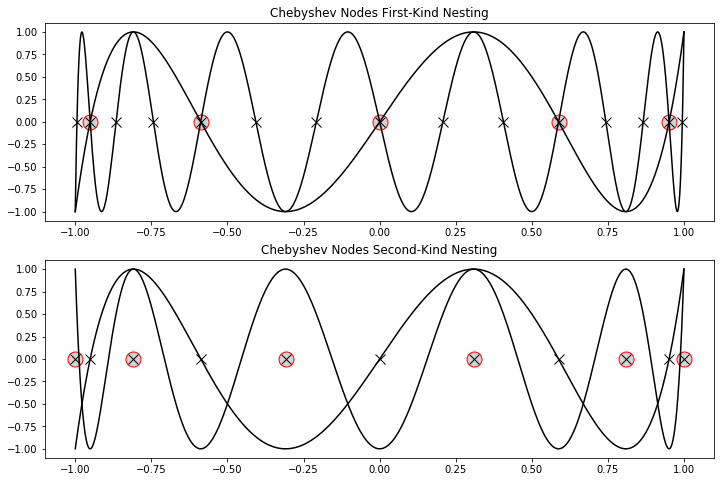

In [ ]:
# First-kind Nesting (3 x)

fig = plt.figure()  
# Membuat figure

fig.set_figwidth(fig.get_figwidth() * 2)  
# Memperlebar figure

fig.set_figheight(fig.get_figheight() * 2)  
# Mempertinggi figure

axes = fig.add_subplot(2, 1, 1)  
# Subplot pertama (atas)

N = 5  
# Jumlah titik dasar

factor = 3  
# Faktor pengali jumlah titik (akan jadi 3N)

# Titik Chebyshev tipe 1 (jumlah N)
x_1 = numpy.cos((2.0 * numpy.arange(1, N + 1) - 1.0) / (2.0 * N) * numpy.pi)

# Titik Chebyshev tipe 1 dengan resolusi lebih tinggi (3N)
x_2 = numpy.cos((2.0 * numpy.arange(1, factor * N + 1) - 1.0) / (2.0 * factor * N) * numpy.pi)

axes.plot(x_1, numpy.zeros(N), "o", color="r", markerfacecolor="lightgray", markersize="15")  
# Plot titik awal (N titik, warna merah)

axes.plot(x_2, numpy.zeros(N * factor), 'kx', markersize="10")  
# Plot titik lebih banyak (3N titik, tanda silang hitam)

x_hat = numpy.linspace(-1, 1, 1000)  
# Grid halus untuk plot polinomial

axes.plot(x_hat, cheb_poly(x_hat, N + 1), 'k')  
# Plot polinomial Chebyshev orde N+1

axes.plot(x_hat, cheb_poly(x_hat, factor * N + 1), 'k')  
# Plot polinomial dengan orde lebih tinggi

axes.set_xlim((-1.1, 1.1))  

axes.set_ylim((-1.1, 1.1))  

axes.set_title("Chebyshev Nodes First-Kind Nesting")  
# Judul plot

# ============================================================
# Second-kind Nesting (2 x)
# ============================================================

axes = fig.add_subplot(2, 1, 2)  
# Subplot kedua (bawah)

N = 5  
# Jumlah titik dasar

factor = 2  
# Faktor pengali (2N)

# Titik Chebyshev tipe 2 (termasuk ujung)
x_1 = numpy.cos(numpy.arange(N + 1) * numpy.pi / N)

# Titik Chebyshev tipe 2 dengan resolusi lebih tinggi (2N)
x_2 = numpy.cos(numpy.arange(factor * N + 1) * numpy.pi / (factor * N))

axes.plot(x_1, numpy.zeros(N + 1), "o", color="r", markerfacecolor="lightgray", markersize="15")  
# Plot titik awal

axes.plot(x_2, numpy.zeros(N * factor + 1), 'kx', markersize="10")  
# Plot titik dengan resolusi lebih tinggi

x_hat = numpy.linspace(-1, 1, 1000)  
# Grid halus

axes.plot(x_hat, cheb_poly(x_hat, N + 1), 'k')  
# Polinomial orde N+1

axes.plot(x_hat, cheb_poly(x_hat, factor * N + 1), 'k')  
# Polinomial orde lebih tinggi

axes.set_xlim((-1.1, 1.1))  

axes.set_ylim((-1.1, 1.1))  

axes.set_title("Chebyshev Nodes Second-Kind Nesting")  
# Judul plot

Salah satu cara untuk mengukur keoptimalan node Chebyshev sebagai himpunan titik interpolasi adalah dengan mempertimbangkan fungsi Lebesgue
$$
\lambda_N(x)  = \sum_{i=0}^N\ell_i(x)
$$
di mana $\ell_i(x)$ adalah fungsi basis Lagrange untuk suatu himpunan $x_i$ tertentu. Nilai maksimum dari fungsi Lebesgue disebut $\Lambda_N$, yaitu konstanta Lebesgue, dan jelas terkait dengan interpolasi Lagrange karena memberikan estimasi awal untuk galat interpolasi. Sayangnya, $\Lambda_N$ tidak terbatas secara seragam terlepas dari node yang digunakan, karena dapat ditunjukkan bahwa
$$
    \Lambda_N > \mathcal{O}(\log N) \quad \text{saat} \quad N \rightarrow \infty
$$
Perhatikan bahwa $\Lambda_N$ adalah norma tak-hingga dari operator linear yang memetakan data ke interpolan pada grid dan interval yang diberikan.

Jika kita menghitung fungsi-fungsi ini untuk titik-titik berjarak sama dan untuk setiap jenis node Chebyshev, kita dapat melihat mengapa Chebyshev mungkin jauh lebih baik untuk interpolasi.

/usr/local/lib/python3.6/site-packages/matplotlib/axes/_base.py:3291: UserWarning: Attempted to set non-positive ylimits for log-scale axis; invalid limits will be ignored.
  'Attempted to set non-positive ylimits for log-scale axis; '


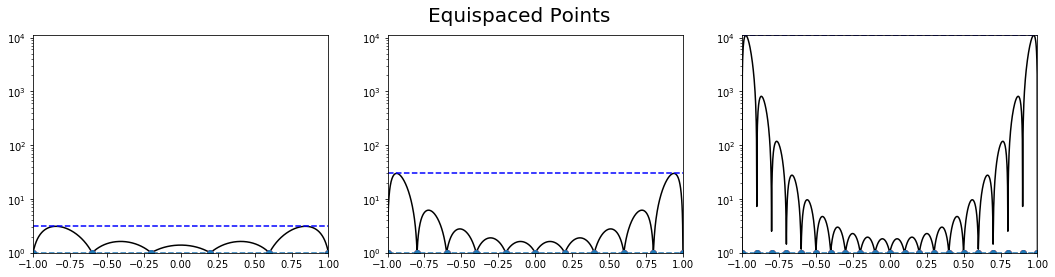

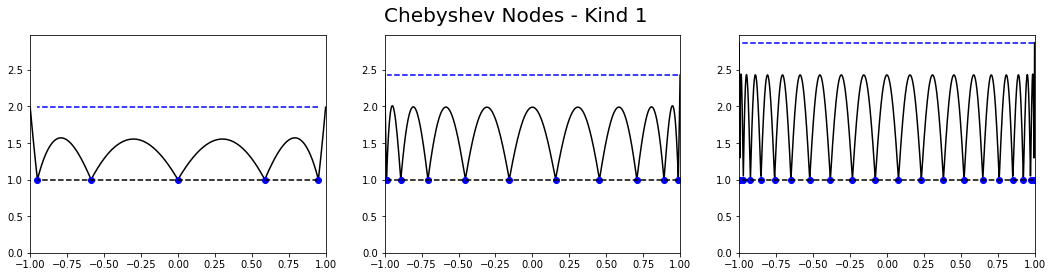

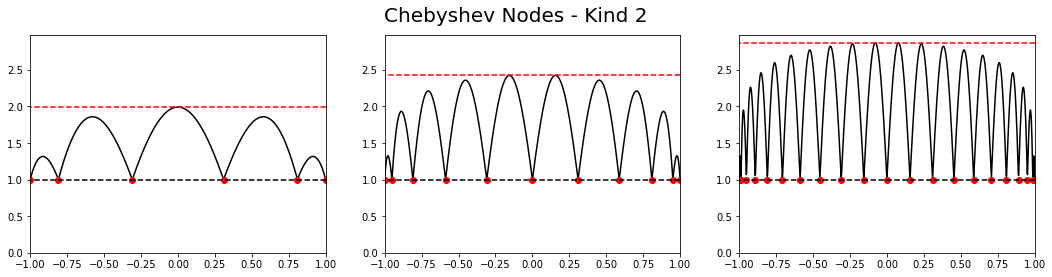

In [ ]:
def lebesgue(x, data):
    """Compute Lebesgue function (jumlah nilai absolut basis Lagrange)"""
    
    lebesgue = numpy.zeros(x.shape[0])  
    # Menyimpan nilai fungsi Lebesgue di setiap titik x

    for i in range(data.shape[0]):  
        # Loop untuk setiap basis Lagrange (L_i)

        lagrange_basis = numpy.ones(x.shape[0])  
        # Inisialisasi L_i(x)

        for j in range(data.shape[0]):  
            # Loop semua titik data

            if i != j:  
                lagrange_basis *= (x - data[j]) / (data[i] - data[j])
                # Rumus basis Lagrange:
                # L_i(x) = Π (x - x_j)/(x_i - x_j)

        lebesgue += numpy.abs(lagrange_basis)  
        # Menjumlahkan nilai absolut semua basis

    return lebesgue  
    # Ini adalah fungsi Lebesgue Λ(x)

# =========================
# PARAMETER
# =========================

N_range = [5, 10, 20]  
# Jumlah titik yang akan diuji

x = numpy.linspace(-1, 1, 1000)  
# Grid halus untuk evaluasi

# ============================================================
# 1. TITIK MERATA (EQUIDISTANT)
# ============================================================

fig = plt.figure()

fig.set_figwidth(fig.get_figwidth() * 3)  
# Memperlebar plot

fig.suptitle("Equispaced Points", fontsize="20")  

y_max = 0.0  
# Menyimpan nilai maksimum global

axes = []

for (i, N) in enumerate([5, 10, 20]):  
    # Loop jumlah titik

    x_hat = -1.0 + 2.0 * numpy.arange(N + 1) / N  
    # Titik merata dari -1 ke 1

    y = lebesgue(x, x_hat)  
    # Hitung fungsi Lebesgue

    axes.append(fig.add_subplot(1, 3, i + 1))  

    axes[i].semilogy(x, y, 'k')  
    # Plot Λ(x) dengan skala log (karena bisa sangat besar)

    axes[i].semilogy(x_hat, numpy.ones(N + 1), 'ro')  
    # Plot posisi titik data

    axes[i].semilogy(x_hat, numpy.ones(N + 1), 'o--')  

    axes[i].plot(x_hat, numpy.ones(N + 1) * numpy.max(y), 'b--')  
    # Garis nilai maksimum Lebesgue

    axes[i].set_xlim((-1, 1))

    y_max = max(y_max, numpy.max(y))  
    # Update nilai maksimum global

for i in range(len(N_range)):
    axes[i].set_ylim((0.0, y_max + 0.1))  
    # Samakan skala semua subplot

# ============================================================
# 2. CHEBYSHEV NODES (TIPE 1)
# ============================================================

fig = plt.figure()

fig.set_figwidth(fig.get_figwidth() * 3)

fig.suptitle("Chebyshev Nodes - Kind 1", fontsize="20")

y_max = 0.0

axes = []

for (i, N) in enumerate(N_range):

    x_hat = numpy.cos((2.0 * numpy.arange(1, N + 1) - 1.0) / (2.0 * N) * numpy.pi)  
    # Titik Chebyshev tipe 1

    y = lebesgue(x, x_hat)  
    # Fungsi Lebesgue

    axes.append(fig.add_subplot(1, 3, i + 1))

    axes[i].plot(x, y, 'k')  
    # Plot Λ(x)

    axes[i].plot(x_hat, numpy.ones(N), 'bo')  
    # Titik data

    axes[i].plot(x_hat, numpy.ones(N), 'k--')  

    axes[i].plot(x_hat, numpy.ones(N) * numpy.max(y), 'b--')  
    # Nilai maksimum

    axes[i].set_xlim((-1, 1))

    y_max = max(y_max, numpy.max(y))

for i in range(len(N_range)):
    axes[i].set_ylim((0.0, y_max + 0.1))

# ============================================================
# 3. CHEBYSHEV EXTREMA (TIPE 2)
# ============================================================

fig = plt.figure()

fig.set_figwidth(fig.get_figwidth() * 3)

fig.suptitle("Chebyshev Nodes - Kind 2", fontsize="20")

y_max = 0.0

axes = []

for (i, N) in enumerate(N_range):

    x_hat = numpy.cos(numpy.arange(N + 1) * numpy.pi / N)  
    # Titik Chebyshev tipe 2 (termasuk ujung -1 dan 1)

    y = lebesgue(x, x_hat)  
    # Fungsi Lebesgue

    axes.append(fig.add_subplot(1, 3, i + 1))

    axes[i].plot(x, y, 'k')  

    axes[i].plot(x_hat, numpy.ones(N + 1), 'ro')  
    # Titik data

    axes[i].plot(x_hat, numpy.ones(N + 1), 'k--')  

    axes[i].plot(x_hat, numpy.ones(N + 1) * numpy.max(y), 'r--')  
    # Nilai maksimum

    axes[i].set_xlim((-1, 1))

    y_max = max(y_max, numpy.max(y))

for i in range(len(N_range)):
    axes[i].set_ylim((0.0, y_max + 0.1))

Untuk benar-benar menunjukkan bahwa node Chebyshev optimal, pertimbangkan polinomial monik $p(z)$ pada bidang kompleks berderajat $N$
$$
    p(z) = \prod^N_{k=1} (z - z_k)
$$
di mana $z_k$ adalah akar-akarnya dengan kemungkinan multiplisitas non-trivial. Dengan memanipulasi sedikit, kita juga dapat menuliskan ekspresi yang terkait
$$\begin{aligned}
    |p(z)| &= \prod^N_{k=1} |z - z_k| \\
    \log|p(z)| &= \sum^N_{k=1} \log|z - z_k|.
\end{aligned}$$

Misalkan
$$
    \phi_N(z) = \frac{1}{N} \sum^N_{k=1} \log |z - z_k|,
$$
Karena $\phi_N(z)$ bersifat *harmonik*, ia memenuhi persamaan Laplace pada bidang kompleks kecuali pada akar-akar $z_k$. Konfigurasi ini dapat dipandang sebagai potensial elektrostatik dengan muatan-muatan pada akar-akar $z_k$. Potensial dari masing-masing muatan adalah
$$
    \frac{\log |z - z_k|}{N}.
$$

Sekarang pertimbangkan hubungan antara $|p(z)|$ dan $\phi_N(z)$. Dari ekspresi sebelumnya kita tahu bahwa
$$
    |p(z)| = e^{N \phi_N(z)}.
$$

Jika $\phi_N(z)$ kira-kira konstan pada interval $[-1, 1]$, maka $|p(z)|$ juga akan konstan. Sebaliknya, jika $\phi_N(z)$ bervariasi, maka variasi dari $|p(z)|$ akan bersifat eksponensial, terutama untuk $N$ yang besar! Dengan memperhatikan perilaku ini, pertimbangkan limit $N \rightarrow \infty$ dan pertimbangkan titik-titik $x_j$ yang terdistribusi dalam $[-1, 1]$ menurut fungsi kerapatan $\rho(x)$ dengan
$$
    \int^1_{-1} \rho(x) dx = 1.
$$

Dari fungsi kerapatan ini kita juga mengetahui jumlah titik grid dalam suatu interval $[a, b]$ sebagai
$$
    1 = N \int^b_a \rho(x) dx.
$$

Dengan menggunakan kerangka ini, kita dapat menuliskan potensial sebagai
$$
    \phi(z) = \int^1_{-1} \rho(x) \log |z - x| dx.
$$
Pada limit $N \rightarrow \infty$ kita dapat tunjukkan untuk titik-titik berjarak sama bahwa
$$
    \phi(z) = -1 +\frac{1}{2} \Re((z + 1) \log(z + 1) - (z-1)\log(z-1)).
$$
Perhatikan bahwa $\phi(0) = -1$ dan $\phi(\pm 1) = -1 + \log 2$ yang mengimplikasikan bahwa jika suatu polinomial $p$ memiliki akar-akar berjarak sama pada $[-1, 1]$, maka nilainya akan $2^N$ kali lebih besar di dekat titik $\pm 1$ dibandingkan di dekat $0$.

Sebaliknya, jika kita mempertimbangkan distribusi untuk titik-titik Chebyshev
$$
    \rho(x) = \frac{1}{\pi \sqrt{1 - x^2}}, \quad x\in[-1,1]
$$
kita dapat tunjukkan bahwa potensial yang dihasilkan adalah
$$
    \phi(z) = \log\frac{\left|z - \sqrt{z^2 - 1} \right |}{2}.
$$

Menariknya, rumus ini memiliki interpretasi yang sederhana: kurva ketinggian (level curves) dari $\phi(z)$ adalah elips-elips dengan fokus $\pm 1$. Nilai $\phi(z)$ di sepanjang elips tersebut adalah logaritma dari setengah jumlah sumbu semi-mayor dan semi-minor dari elips tersebut. Elips degenerat $[-1, 1]$ juga merupakan kurva ketinggian dan memiliki nilai konstan $-\log 2$. Hal ini ternyata optimal dengan polinomial yang tumbuh sebesar
$$
    |p(z)| = e^{N \phi(x)} \approx 2^{-N}, ~~~ x\in[-1,1].
$$

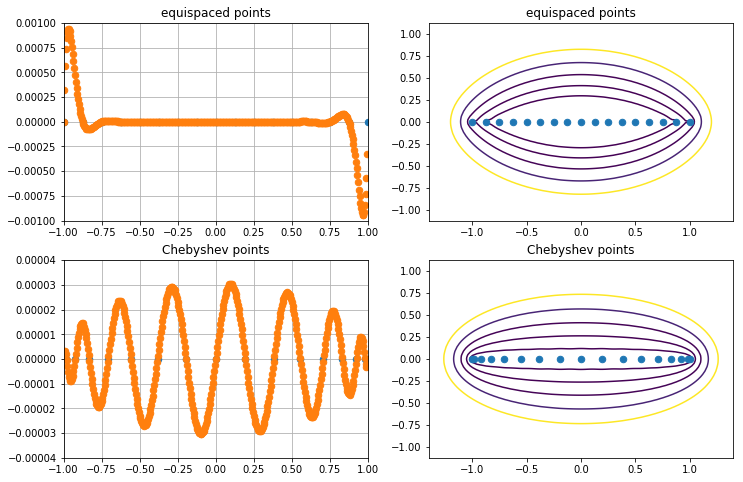

In [ ]:
# Adapted from program 10 in Trefethen - "Spectral Methods for MATLAB"

N = 16  
# Jumlah titik (akan menghasilkan polinomial derajat 16)

fig, axes = plt.subplots(2, 2)  
# Membuat 4 subplot (2 baris, 2 kolom)

fig.set_figwidth(fig.get_figwidth() * 2)  
# Memperlebar figure

fig.set_figheight(fig.get_figheight() * 2)  
# Mempertinggi figure

for (i, point_distribution) in enumerate(("equispaced points", "Chebyshev points")):
    # Loop dua jenis distribusi titik:
    # i = 0 → titik merata
    # i = 1 → titik Chebyshev

    if i == 0:
        x = -1.0 + 2.0 * numpy.arange(N + 1) / N  
        # Titik merata dari -1 ke 1
    else:
        x = numpy.cos(numpy.pi * numpy.arange(N+1) / N)  
        # Titik Chebyshev (termasuk ujung)

    # =========================
    # MEMBENTUK POLINOMIAL
    # =========================

    p = numpy.poly(x)  
    # Membuat polinomial dengan akar di titik x
    # Artinya: p(x_i) = 0 untuk semua titik data

    # =========================
    # PLOT p(x) di domain [-1,1]
    # =========================

    x_fine = numpy.arange(-1, 1, .005)  
    # Grid halus untuk plot

    axes[i, 0].plot(x, 0*x, '.', markersize=13)  
    # Plot titik akar (semua di y = 0)

    axes[i, 0].plot(x_fine, numpy.polyval(p, x_fine), '.', markersize=13)  
    # Plot nilai polinomial p(x)

    axes[i, 0].grid(True)

    axes[i, 0].set_title(point_distribution)  

    axes[i, 0].set_xlim((-1, 1))

    if i == 0:
        axes[i, 0].set_ylim((-1e-3, 1e-3))  
        # Untuk equispaced → nilai p(x) bisa besar (perlu zoom kecil)
    else:
        axes[i, 0].set_ylim((-4e-5, 4e-5))  
        # Untuk Chebyshev → jauh lebih kecil (lebih stabil)

    # =========================
    # PLOT DI BIDANG KOMPLEKS
    # =========================

    axes[i, 1].plot(x.real, x.imag, '.', markersize=13)  
    # Plot titik akar di bidang kompleks (semua real → imag = 0)

    axes[i, 1].set_xlim((-1.4, 1.4))

    axes[i, 1].set_ylim((-1.12, 1.12))

    X, Y = numpy.meshgrid(numpy.arange(-1.4, 1.4, 0.02), 
                          numpy.arange(-1.12, 1.12, 0.02))
    # Membuat grid 2D (untuk bidang kompleks)

    levels = 10**(numpy.arange(-4.0, 1.0))  
    # Level kontur (log scale)

    axes[i, 1].contour(X, Y, numpy.abs(numpy.polyval(p, X + 1j * Y)), levels)
    # Plot kontur |p(z)| di bidang kompleks
    # z = X + iY

    axes[i, 1].set_title(point_distribution)

### Diferensiasi Chebyshev

Salah satu cara kita menurunkan beda hingga adalah dengan menginterpolasi polinomial melalui titik-titik stensil dan mengambil turunan dari interpolan yang dihasilkan. Kita dapat melakukan hal yang sama untuk mencari matriks diferensiasi Chebyshev. Karena setiap interpolan bersifat unik berdasarkan titik-titik yang dilaluinya, kita hanya perlu menentukan turunannya berdasarkan node Chebyshev itu sendiri.

Misalkan
$$
   p_N(x_j) = v_j, \quad 0 \leq j \leq N 
$$
adalah polinomial berderajat $N$, maka turunan yang dihasilkan adalah
$$
    p'_N(x_j) = w_j.
$$

Karena operasi ini bersifat linear, kita dapat membentuknya sebagai perkalian dengan matriks:
$$
    \mathbf{w} = \mathbf{D}_N \mathbf{v}
$$

Sebagai contoh, pertimbangkan kasus $N=1$, maka titik-titik interpolasinya adalah $x_0 = 1$ dan $x_1 = -1$ sehingga menghasilkan
$$
    p_1(x) = \frac{1}{2} (1  + x)v_0 + \frac{1}{2}(1 - x)v_1
$$
yang memberikan
$$
    p'_1(x) = \frac{1}{2}(v_0 - v_1).
$$
Matriks yang dihasilkan adalah
$$
    D_1 = \begin{bmatrix}
        1/2 & -1/2 \\
        1/2 & -1/2
    \end{bmatrix}.
$$

Untuk kasus $N=2$ kita memiliki titik-titik $x_0 = 1$, $x_1 = 0$, dan $x_2 = -1$ dengan interpolan kuadratik
$$
    p_2(x) = \frac{1}{2} x ( 1 + x) v_0 + (1+x)(1-x)v_1 + \frac{1}{2} x (x-1) v_2
$$
yang menghasilkan turunan
$$
    p'_2(x) = (x+ 1/2) v_0 - 2 x v_1 + (x-1/2)v_2
$$
dan matriks diferensiasi
$$
    D_2 = \begin{bmatrix}
        3/2  & -2 & 1/2 \\
        1/2  &  0 & -1/2 \\
        -1/2 &  2 & -3/2
    \end{bmatrix}.
$$

Perhatikan bahwa untuk kedua kasus ini, rumus-rumus tersebut memiliki bentuk yang familiar, namun matriks diferensiasinya memiliki sifat satu sisi tambahan. Untuk aproksimasi orde tinggi, metode ini menyimpang dari metode beda hingga biasa karena jarak titik-titik yang tidak seragam. Secara umum, matriks diferensiasi Chebyshev berbentuk
$$\begin{aligned}
    (D_N)_{00} = \frac{2 N^2 + 1}{6}, & & (D_N)_{NN} = -\frac{2N^2 + 1}{6}, \\
    (D_N)_{jj} = \frac{-x_j}{2(1 - x_j^2)}, & & j=1,\ldots,N-1 \\
    (D_N)_{ij} = \frac{c_i(-1)^{i+j}}{c_j (x_i - x_j)}, & & i\neq j, ~~ i,j = 0, \ldots, N
\end{aligned}$$
dengan
$$
    c_i = \left \{ \begin{aligned}
        2, & & i=0 \text{ atau } N \\
        1, & & \text{untuk lainnya}.
    \end{aligned} \right .
$$

In [ ]:
# Based on Trefethen cheb function dan referensi pseudospectral differentiation

import operator  # Untuk operasi perkalian (dipakai di reduce)
import scipy  # Library scientific computing (mirip NumPy, tapi lebih luas)
from functools import reduce  # Untuk mengalikan banyak elemen sekaligus

def cheb(N):
    # Fungsi untuk membuat:
    # 1. Titik Chebyshev
    # 2. Differentiation matrix (D)

    x = numpy.cos(numpy.pi * numpy.arange(N+1) / N)  
    # Titik Chebyshev tipe 2 (termasuk -1 dan 1)

    e = scipy.ones((N + 1, 1))  
    # Vektor kolom berisi 1 (ukuran N+1)

    Xdiff = scipy.outer(x, e) - scipy.outer(e, x) + scipy.identity(N + 1)  
    # Matriks selisih:
    # Xdiff[i,j] = x_i - x_j
    # Ditambah identity supaya tidak nol di diagonal (menghindari pembagian nol)

    xprod = -reduce(operator.mul, Xdiff)  
    # Mengalikan semua elemen per baris:
    # Ini menghasilkan produk ∏ (x_i - x_j)
    # Digunakan untuk bobot (weights)

    W = scipy.outer(1.0 / xprod, e)  
    # Matriks bobot:
    # W[i,j] = 1 / produk(x_i - x_j)

    D = W / scipy.multiply(W.T, Xdiff)  
    # Membentuk differentiation matrix:
    # D[i,j] = W[i] / (W[j] * (x_i - x_j))

    d = 1 - sum(D)  
    # Menghitung elemen diagonal:
    # agar jumlah baris = 0 (sifat turunan)

    for k in range(0, N+1):  
        # Loop untuk setiap diagonal

        D[k,k] = d[k]  
        # Mengisi elemen diagonal dengan nilai yang benar

    return -D.T, x  
    # Mengembalikan:
    # -D.T = differentiation matrix final
    # x = titik Chebyshev

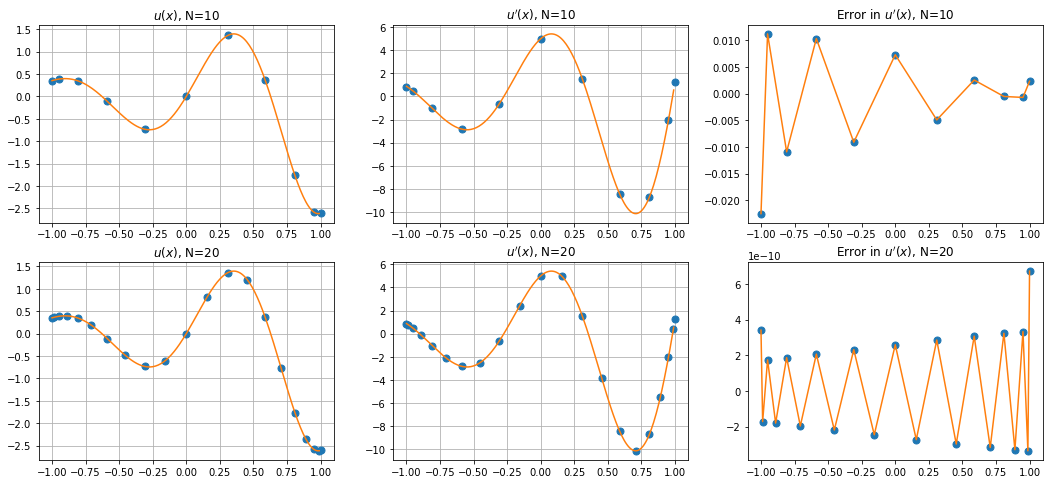

In [ ]:
# Test out some differentiation on a smooth function

u = lambda x: numpy.exp(x) * numpy.sin(5.0 * x)  
# Fungsi u(x) = e^x * sin(5x)

u_prime = lambda x: numpy.exp(x) * (numpy.sin(5.0 * x) + 5.0 * numpy.cos(5.0 * x))  
# Turunan analitik dari u(x)

x_fine = numpy.arange(-1, 1, 0.01)  
# Grid halus untuk plot referensi

fig, axes = plt.subplots(2, 3)  
# Membuat subplot 2 baris dan 3 kolom

fig.set_figwidth(fig.get_figwidth() * 3)  
# Memperlebar figure

fig.set_figheight(fig.get_figheight() * 2)  
# Mempertinggi figure

for (i, N) in enumerate((10, 20)):  
    # Loop untuk dua nilai N (jumlah titik Chebyshev)

    D, x = cheb(N)  
    # Mengambil differentiation matrix D dan titik Chebyshev x

    axes[i, 0].plot(x, u(x), '.', markersize=14)  
    # Plot nilai u(x) pada titik Chebyshev

    axes[i, 0].grid(True)  

    axes[i, 0].plot(x_fine, u(x_fine))  
    # Plot fungsi asli pada grid halus

    axes[i, 0].set_title('$u(x)$, N=%s' % N)  

    axes[i, 1].plot(x, numpy.dot(D, u(x)), '.', markersize=14)  
    # Plot turunan numerik (D * u)

    axes[i, 1].grid(True)  

    axes[i, 1].plot(x_fine, u_prime(x_fine))  
    # Plot turunan analitik

    axes[i, 1].set_title("$u'(x)$, N=%s" % N)  
    
    error = numpy.dot(D, u(x)) - u_prime(x)  
    # Menghitung error antara turunan numerik dan analitik

    axes[i, 2].plot(x, error, '.', markersize=14)  
    # Plot error pada titik Chebyshev

    axes[i, 2].plot(x, error)  
    # Garis error

    axes[i, 2].set_title("Error in $u'(x)$, N=%s" % N)  

plt.show()  
# Menampilkan plot

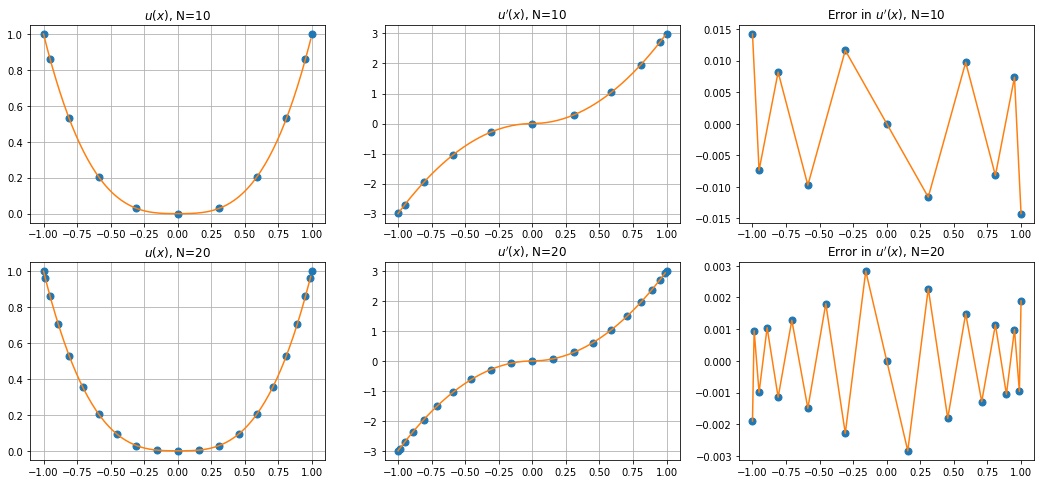

In [ ]:
# Bounded Variation in 3rd derivative

u = lambda x: numpy.abs(x)**3  
# Fungsi u(x) = |x|^3

u_prime = lambda x: 3.0 * x * numpy.abs(x)  
# Turunan analitik u'(x)

x_fine = numpy.arange(-1, 1, 0.01)  
# Grid halus untuk referensi plot

fig, axes = plt.subplots(2, 3)  
# Membuat subplot 2x3

fig.set_figwidth(fig.get_figwidth() * 3)  
# Memperlebar figure

fig.set_figheight(fig.get_figheight() * 2)  
# Mempertinggi figure

for (i, N) in enumerate((10, 20)):  
    # Loop untuk dua nilai N

    D, x = cheb(N)  
    # Mengambil differentiation matrix dan titik Chebyshev

    axes[i, 0].plot(x, u(x), '.', markersize=14)  
    # Plot nilai fungsi pada titik Chebyshev

    axes[i, 0].grid(True)  

    axes[i, 0].plot(x_fine, u(x_fine))  
    # Plot fungsi asli (halus)

    axes[i, 0].set_title('$u(x)$, N=%s' % N)  

    axes[i, 1].plot(x, numpy.dot(D, u(x)), '.', markersize=14)  
    # Plot turunan numerik

    axes[i, 1].grid(True)  

    axes[i, 1].plot(x_fine, u_prime(x_fine))  
    # Plot turunan analitik

    axes[i, 1].set_title("$u'(x)$, N=%s" % N)  
    
    error = numpy.dot(D, u(x)) - u_prime(x)  
    # Menghitung error

    axes[i, 2].plot(x, error, '.', markersize=14)  
    # Plot error (titik)

    axes[i, 2].plot(x, error)  
    # Plot error (garis)

    axes[i, 2].set_title("Error in $u'(x)$, N=%s" % N)  

plt.show()  
# Menampilkan hasil

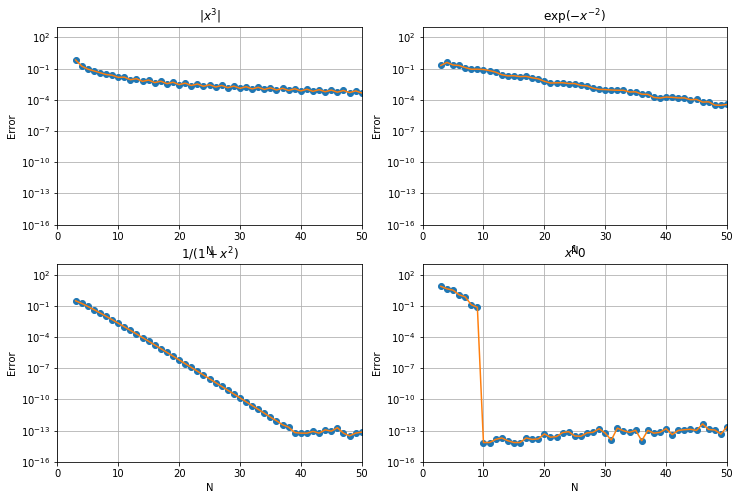

In [ ]:
# Compare errors more carefully (program 12 in Trefethen)
N_max = 50
error = numpy.zeros((4, N_max - 2))
N_range = numpy.arange(3, N_max + 1)
for (i, N) in enumerate(N_range):
    D, x = cheb(N)
    # 3rd derivative of bounded variation
    v = numpy.abs(x)**3
    v_prime = numpy.abs(x) * x * 3.0
    error[0, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.infty)
    # C_\infty function# Compare errors more carefully (program 12 in Trefethen)

N_max = 50  
# Nilai maksimum N (jumlah titik Chebyshev)

error = numpy.zeros((4, N_max - 2))  
# Menyimpan error untuk 4 jenis fungsi

N_range = numpy.arange(3, N_max + 1)  
# Range N dari 3 sampai 50

for (i, N) in enumerate(N_range):  
    # Loop untuk setiap N

    D, x = cheb(N)  
    # Ambil differentiation matrix dan titik Chebyshev

    # =========================
    # 1. Fungsi |x|^3
    # =========================
    v = numpy.abs(x)**3  
    # Fungsi

    v_prime = numpy.abs(x) * x * 3.0  
    # Turunan analitik

    error[0, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.infty)  
    # Hitung error maksimum

    # =========================
    # 2. Fungsi sangat halus (C-infinity)
    # =========================
    v = numpy.exp(-x**(-2))  
    # Fungsi sangat halus (smooth)

    v_prime = 2 * v / x**3  
    # Turunan analitik

    error[1, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.infty)  

    # =========================
    # 3. Fungsi analitik
    # =========================
    v = 1.0 / (1.0 + x**2)  

    v_prime = -2.0 * x * v**2  

    error[2, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.infty)  

    # =========================
    # 4. Polinomial
    # =========================
    v = x**10  

    v_prime = 10 * x**9  

    error[3, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.infty)  

# =========================
# PLOT ERROR
# =========================

fig = plt.figure()  

fig.set_figwidth(fig.get_figwidth() * 2)  
# Memperlebar plot

fig.set_figheight(fig.get_figheight() * 2)  
# Mempertinggi plot

titles = ['$|x^3|$', '$\\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']  
# Judul masing-masing fungsi

for (i, title) in enumerate(titles):  
    # Loop tiap subplot

    axes = fig.add_subplot(2, 2, i + 1)  

    axes.semilogy(N_range, error[i, :], '.', markersize=12)  
    # Plot titik error (skala log)

    axes.semilogy(N_range, error[i, :])  
    # Plot garis error

    axes.set_xlim((0, N_max))  

    axes.set_ylim((1e-16, 1e3))  
    # Rentang error (log scale)

    axes.grid(True)  

    axes.set_xlabel("N")  

    axes.set_ylabel("Error")  

    axes.set_title(title)  
    v = numpy.exp(-x**(-2))
    v_prime = 2 * v / x**3
    error[1, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.infty)
    # Analytic on [-1, 1]
    v = 1.0 / (1.0 + x**2)
    v_prime = -2.0 * x * v**2
    error[2, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.infty)
    # Polynomial
    v = x**10
    v_prime = 10 * x**9
    error[3, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.infty)
    
# Plot errors
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
titles = ['$|x^3|$', '$\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']
for (i, title) in enumerate(titles):
    axes = fig.add_subplot(2, 2, i + 1)
    axes.semilogy(N_range, error[i, :], '.', markersize=12)
    axes.semilogy(N_range, error[i, :])
    axes.set_xlim((0, N_max))
    axes.set_ylim((1e-16, 1e3))
    axes.grid(True)
    axes.set_xlabel("N")
    axes.set_ylabel("Error")
    axes.set_title(title)

Sebagai aplikasi lain dari matriks diferensiasi Chebyshev, kita juga dapat menggunakannya untuk menghitung solusi dari masalah Poisson dengan kondisi batas non-periodik. Pertimbangkan masalah
$$
    u_{xx} = e^{4x},\quad \Omega = [-1, 1], \quad u(\pm 1) = 0
$$
yang memiliki solusi
$$
    u(x) = \frac{e^{4x} - x \sinh(4) - \cosh(4)}{16}.
$$
Melanjutkan dari sebelumnya, kita memiliki
$$
    D^2_N U = F
$$
yang kemudian dapat diinvers untuk menemukan solusinya.

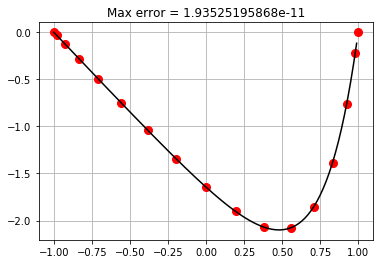

In [ ]:
# Compare errors more carefully (program 12 in Trefethen)

N_max = 50  
# Nilai maksimum N (jumlah titik Chebyshev)

error = numpy.zeros((4, N_max - 2))  
# Menyimpan error untuk 4 jenis fungsi

N_range = numpy.arange(3, N_max + 1)  
# Range N dari 3 sampai 50

for (i, N) in enumerate(N_range):  
    # Loop untuk setiap N

    D, x = cheb(N)  
    # Ambil differentiation matrix dan titik Chebyshev

    # =========================
    # 1. Fungsi |x|^3
    # =========================
    v = numpy.abs(x)**3  
    # Fungsi

    v_prime = numpy.abs(x) * x * 3.0  
    # Turunan analitik

    error[0, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.infty)  
    # Hitung error maksimum

    # =========================
    # 2. Fungsi sangat halus (C-infinity)
    # =========================
    v = numpy.exp(-x**(-2))  
    # Fungsi sangat halus (smooth)

    v_prime = 2 * v / x**3  
    # Turunan analitik

    error[1, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.infty)  

    # =========================
    # 3. Fungsi analitik
    # =========================
    v = 1.0 / (1.0 + x**2)  

    v_prime = -2.0 * x * v**2  

    error[2, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.infty)  

    # =========================
    # 4. Polinomial
    # =========================
    v = x**10  

    v_prime = 10 * x**9  

    error[3, i] = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.infty)  

# =========================
# PLOT ERROR
# =========================

fig = plt.figure()  

fig.set_figwidth(fig.get_figwidth() * 2)  
# Memperlebar plot

fig.set_figheight(fig.get_figheight() * 2)  
# Mempertinggi plot

titles = ['$|x^3|$', '$\\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']  
# Judul masing-masing fungsi

for (i, title) in enumerate(titles):  
    # Loop tiap subplot

    axes = fig.add_subplot(2, 2, i + 1)  

    axes.semilogy(N_range, error[i, :], '.', markersize=12)  
    # Plot titik error (skala log)

    axes.semilogy(N_range, error[i, :])  
    # Plot garis error

    axes.set_xlim((0, N_max))  

    axes.set_ylim((1e-16, 1e3))  
    # Rentang error (log scale)

    axes.grid(True)  

    axes.set_xlabel("N")  

    axes.set_ylabel("Error")  

    axes.set_title(title)  

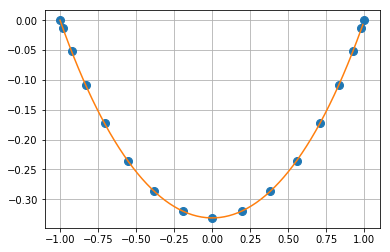

In [ ]:
# Adapted from Trefethen program 13

f = lambda x: numpy.exp(4.0 * x)  
# Fungsi ruas kanan f(x)

u_true = lambda x: (numpy.exp(4.0 * x) - x * numpy.sinh(4.0) - numpy.cosh(4.0)) / 16.0  
# Solusi analitik dari persamaan diferensial

N = 16  
# Jumlah titik Chebyshev

x_fine = numpy.arange(-1, 1, 0.01)  
# Grid halus untuk plot solusi eksak

# =========================
# DIFFERENTIATION MATRIX
# =========================

D, x = cheb(N)  
# Ambil matriks turunan pertama dan titik Chebyshev

D2 = numpy.dot(D, D)[1:-1, 1:-1]  
# Matriks turunan kedua (D^2)
# [1:-1] → menghapus boundary (Dirichlet boundary condition)

# =========================
# MENYELESAIKAN SISTEM
# =========================

U = numpy.zeros(N + 1)  
# Inisialisasi solusi numerik

U[1:-1] = numpy.linalg.solve(D2, f(x[1:-1]))  
# Menyelesaikan sistem linear:
# D2 * U = f(x) (tanpa boundary)

error = numpy.linalg.norm(U - u_true(x), ord=numpy.infty)  
# Menghitung error maksimum

# =========================
# PLOT HASIL
# =========================

fig = plt.figure()  

axes = fig.add_subplot(1, 1, 1)  

axes.plot(x, U, 'r.', markersize=16)  
# Plot solusi numerik

axes.plot(x_fine, u_true(x_fine), 'k')  
# Plot solusi analitik

axes.grid(True)  

axes.set_title("Max error = %s" % error)  

plt.show()  
# Menampilkan plot

Kita juga dapat menangani masalah berdimensi lebih tinggi. Pertimbangkan PDE
$$
    u_{xx} + u_{yy} = 10 \sin(8 x (y - 1)), \quad -1 < x,~y < 1
$$
dengan $u = 0$ pada batasnya. Kita dapat terus menggunakan matriks diferensiasi yang kita gunakan sebelumnya. Jika kita mengurutkan variabel yang tidak diketahui dalam urutan alami seperti sebelumnya, kita dapat kembali menggunakan produk Kronecker untuk menyusun matriks-matriks yang relevan.

Misalnya, jika kita mempertimbangkan kasus $N=4$, kita memiliki matriks diferensiasi dalam satu dimensi
$$
    D^2_4 = \begin{bmatrix}
        -14 & 6 & -2 \\
        4 & -6 & 4 \\
        -2 & 6 & -14
    \end{bmatrix}
$$
yang dapat mengaproksimasi matriks dimensi-x dengan urutan yang ditentukan sebagai `kron(I, D2)` yang menghasilkan
$$
    I \otimes D^2_N = \begin{bmatrix}
        -14 & 6 & -2 \\
        4 & -6 & 4 \\
        -2 & 6 & -14 \\
        & & & -14 & 6 & -2 \\
        & & & 4 & -6 & 4 \\
        & & & -2 & 6 & -14 \\
        & & & & & & -14 & 6 & -2 \\
        & & & & & & 4 & -6 & 4 \\
        & & & & & & -2 & 6 & -14
    \end{bmatrix}.
$$

Turunan dalam arah-y akan menjadi `kron(D2, I)` yang menghasilkan
$$
    I \otimes D^2_N = \begin{bmatrix}
        -14 &     &     &   6 &     &     &  -2 &     &     \\
            & -14 &     &     &   6 &     &     &  -2 &     \\
            &     & -14 &     &     &   6 &     &     &  -2 \\
          4 &     &     &  -6 &     &     &   4 &     &     \\
            &   4 &     &     &  -6 &     &     &   4 &     \\
            &     &   4 &     &     &  -6 &     &     &   4 \\
         -2 &     &     &   6 &     &     & -14 &     &     \\
            &  -2 &     &     &   6 &     &     & -14 &     \\
            &     &  -2 &     &     &   6 &     &     & -14 \\
    \end{bmatrix}.
$$

Secara keseluruhan, kita dapat memperoleh operator Laplacian yang didiskritisasi dengan menjumlahkan kedua matriks di atas, yaitu
$$
    L_N = I \otimes D^2_N + D^2_N \otimes I.
$$

Kekurangan dari penggunaan matriks-matriks ini dibandingkan dengan beda hingga adalah matriksnya tidak terlalu sparse (jarang). Untungnya, jika kita dapat memanfaatkan konvergensi spektral dari metode ini, kita akan dapat menggunakan titik yang jauh lebih sedikit untuk menyelesaikan sistem tersebut.

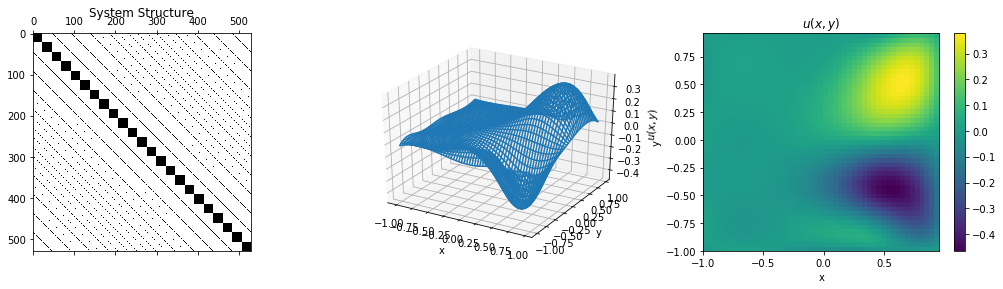

In [ ]:
# Based on Trefethen program 16

import mpl_toolkits.mplot3d  
# Untuk plotting 3D

import scipy.interpolate  
# Untuk interpolasi 2D (smoothing hasil)

f = lambda x, y: 10.0 * numpy.sin(8.0 * x * (y - 1.0))  
# Fungsi sumber f(x, y)

N = 24  
# Jumlah titik Chebyshev

D, x = cheb(N)  
# Matriks turunan dan titik Chebyshev

X, Y = numpy.meshgrid(x[1:-1], x[1:-1])  
# Grid 2D tanpa boundary

X = X.flatten()  
# Ubah ke vektor 1D

Y = Y.flatten()  
# Ubah ke vektor 1D

D2 = numpy.dot(D, D)  
# Matriks turunan kedua

D2 = D2[1:-1, 1:-1]  
# Hilangkan boundary (Dirichlet condition)

I = numpy.eye(N - 1)  
# Matriks identitas

L = numpy.kron(I, D2) + numpy.kron(D2, I)  
# Operator Laplacian 2D (Kronecker product)

# =========================
# MENYELESAIKAN SISTEM
# =========================

U = numpy.linalg.solve(L, f(X, Y))  
# Menyelesaikan sistem linear L * U = f

# =========================
# PLOT STRUKTUR DAN HASIL
# =========================

fig = plt.figure()  

fig.set_figwidth(fig.get_figwidth() * 3)  
# Memperlebar figure

# =========================
# 1. STRUKTUR MATRIX
# =========================

axes = fig.add_subplot(1, 3, 1)  

axes.spy(L)  
# Visualisasi sparsity matrix

axes.set_title("System Structure")  

# =========================
# 2. MEMBENTUK GRID HASIL
# =========================

u = numpy.zeros((N + 1, N + 1))  
# Inisialisasi solusi 2D

u[1:-1, 1:-1] = U.reshape(N - 1, N - 1)  
# Masukkan solusi interior

X, Y = numpy.meshgrid(x, x)  
# Grid lengkap

x_fine = numpy.arange(-1, 1, 0.04)  
# Grid halus

X_fine, Y_fine = numpy.meshgrid(x_fine, x_fine)  

u_interpolant = scipy.interpolate.bisplrep(X, Y, u, s=1)  
# Interpolasi spline 2D

u_fine = scipy.interpolate.bisplev(x_fine, x_fine, u_interpolant)  
# Evaluasi hasil interpolasi

# =========================
# 3. PLOT 3D
# =========================

axes = fig.add_subplot(1, 3, 2, projection='3d')  

axes.plot_wireframe(X_fine, Y_fine, u_fine)  
# Plot permukaan 3D

axes.set_xlabel('x')  

axes.set_ylabel('y')  

axes.set_zlabel('$u(x,y)$')  

# =========================
# 4. PLOT HEATMAP
# =========================

axes = fig.add_subplot(1, 3, 3)  

plot = axes.pcolor(X_fine, Y_fine, u_fine)  
# Plot warna (heatmap)

axes.set_xlabel('x')  

axes.set_ylabel('y')  

axes.set_title('$u(x,y)$')  

fig.colorbar(plot)  
# Menambahkan colorbar

plt.show()  
# Menampilkan hasil

## FFT dan Chebyshev

FFT adalah alat yang sangat kuat yang benar-benar membuat metode spektral menjadi menarik, tetapi kita hanya melihat bagaimana FFT dapat digunakan pada deret Fourier. Ternyata serangkaian kesetaraan akan memungkinkan kita untuk menggunakan FFT pada deret Chebyshev juga.

![Hubungan antara x, z, dan \theta (dari Trefethen gambar 8.1)](./images/relationships.png)

Misalkan $z \in \mathbb C$ dengan $|z| = 1$, misalkan $\theta$ adalah argumen dari $z$, yaitu $z = e^{i \theta}$ (perhatikan bahwa $\theta$ hanya unik hingga kelipatan $2 \pi$), dan $x$ adalah bagian riil dari $z$ sehingga $x = \Re z = \cos \theta$. Untuk setiap $x \in [-1, 1]$ terdapat dua nilai $z$ yang bersesuaian dengan naik dan turun ke $z$ yang bersesuaian pada lingkaran satuan, yaitu
$$
    x = \Re z = \frac{1}{2} (z + z^{-1}) = \cos \theta.
$$

Sekarang pertimbangkan polinomial Chebyshev $T_n(x)$ di mana polinomial ke-$n+1$ adalah
$$
    T_{n+1}(x) = \frac{1}{2} (z^{n+1} + z^{-n-1}) = \frac{1}{2} (z^n + z^{-n}) - \frac{1}{2}(z^{n-1} + z^{1-n})
$$
yang juga bersesuaian dengan relasi rekurensi untuk polinomial Chebyshev, yaitu
$$
    T_{n+1}(x) = 2 x T_n(x) - T_{n-1}(x).
$$
Perhatikan bahwa kita sebenarnya menggunakan hubungan antara $x$ dan $z$ yang kita peroleh dari hubungan lingkaran satuan.

Karena kita juga tahu bahwa $T_n(x)$ adalah polinomial berderajat $n$, kita dapat menggunakan polinomial Chebyshev sebagai basis
$$
    p(x) = \sum^\infty_{n=0} a_n T_n(x), \quad x \in [-1, 1].
$$
Ini juga bersesuaian dengan polinomial Laurent berderajat $N$ dalam $z$ dan $z^{-1}$ di mana $z^n$ dan $z^{-n}$ memiliki koefisien yang sama
$$
    \tilde{p}(z) = \frac{1}{2} \sum^\infty_{n=0} a_n (z^n + z^{-n}), \quad |z| = 1,
$$
yang juga dikenal sebagai resiprokal-diri. Terdapat pula polinomial lain dalam $\theta$ yang periodik $2 \pi$ sehingga
$$
    P(\theta) = \sum^\infty_{n=0} a_n \cos n \theta, \quad \theta \in \mathbb R.
$$

Jadi ke mana arah semua ini? Kita tahu bahwa polinomial-polinomial ini ekuivalen jika kita memiliki hubungan yang telah didefinisikan sebelumnya antara variabel bebas $x$, $z$, dan $\theta$. Sekarang mari kita pertimbangkan bagaimana polinomial-polinomial ini akan berperilaku sebagai interpolan.

Misalkan $f(x)$ adalah suatu fungsi sembarang pada $[-1, 1]$, maka kita dapat membentuk fungsi resiprokal-diri $\tilde{f~}(z)$ dengan
$$
    \tilde{f~}(z) = f\left(1/2 (z + z^{-1})\right)
$$
dan bersesuaian dengan
$$
    F(\theta) = f(\cos \theta).
$$

Sekarang mari kita lihat bagaimana versi terpotong dari polinomial kita menginterpolasi fungsi-fungsi ini. Interpolan akan memiliki titik-titik nodal pada
$$
    \theta_j = j \pi / N, \quad z_j = e^{i\theta_j}, \quad \text{dan} \quad x_j = \cos \theta_j = \Re z_j.
$$
Dengan ini, kita dapat membuat pernyataan berikut mengenai polinomial terpotong ini terhadap suatu fungsi $f(z)$:
- $P(\theta)$ menginterpolasi $F(\theta)$ (dengan asumsi bahwa $F$ genap dan periodik $2\pi$) pada titik-titik $\theta_j$ yang berjarak sama,
- $\tilde{p~}(z)$ menginterpolasi $\tilde{f~}(z)$ pada akar-akar satuan $z_j$,
- $p(x)$ menginterpolasi $f(x)$ pada titik-titik Chebyshev $x_j$.

Kita sekarang mulai melihat bagaimana kita dapat menggunakan FFT dengan deret Chebyshev berkat kesetaraan-kesetaraan ini. Proses dasarnya adalah sebagai berikut:
1. Diberikan $f$ sembarang, cari interpolan polinomial trigonometri $Q$ dari $F$,
2. Diferensiasi interpolan ini dalam ruang Fourier, dan
3. Transformasi kembali ke domain asli pada $x \in [-1, 1]$.

In [ ]:
# Based on Trefethen chebfft function

def chebfft(v):
    N = v.shape[0] - 1  
    # Jumlah interval (karena ada N+1 titik Chebyshev)

    if N == 0:
        return 0  
        # Kasus trivial (tidak ada turunan)

    x = numpy.cos(numpy.arange(N+1) * numpy.pi / N)  
    # Titik Chebyshev (mapping dari θ ke x)

    ii = numpy.arange(N)  
    # Indeks untuk perhitungan

    # =========================
    # TRANSFORM x → θ
    # =========================

    V = numpy.hstack((v, v[N-1:0:-1]))  
    # Membuat ekstensi genap dari data (untuk FFT)
    # v diperpanjang agar periodik

    U = fft.fft(V).real  
    # FFT dari data (diambil bagian real)

    wave_numbers = numpy.hstack((ii, [0], numpy.arange(1-N, 0)))  
    # Bilangan gelombang (frekuensi Fourier)

    W = fft.ifft(1j * wave_numbers * U).real  
    # Turunan di ruang Fourier (i*k*U), lalu inverse FFT

    w = numpy.zeros((N+1))  
    # Menyimpan hasil turunan di titik Chebyshev

    # =========================
    # TRANSFORM θ → x
    # =========================

    w[1:N] = -W[1:N] / numpy.sqrt(1.0 - x[1:N]**2)  
    # Transform kembali ke domain x (interior points)

    w[0] = numpy.sum(ii**2 * U[ii]) / N + 0.5 * N * U[N]  
    # Nilai turunan di x = 1 (endpoint kiri)

    w[-1] = numpy.sum((-1)**(ii + 1) * ii**2 * U[ii]) / N + 0.5 * (-1)**(N+1) * N * U[N]  
    # Nilai turunan di x = -1 (endpoint kanan)

    return w  
    # Mengembalikan turunan fungsi di titik Chebyshev

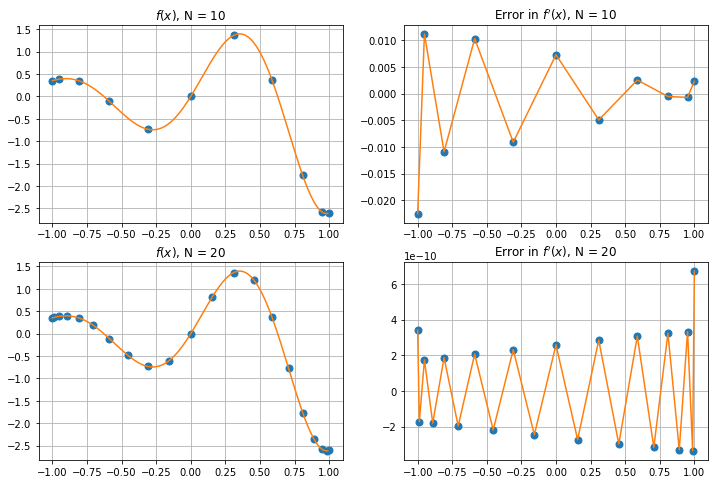

In [20]:
# Adaptation of program 18 in Trefethen
f = lambda x: numpy.exp(x) * numpy.sin(5.0 * x)
f_prime = lambda x: numpy.exp(x) * (numpy.sin(5.0 * x) + 5.0 * numpy.cos(5.0 * x))
x_fine = numpy.arange(-1, 1, 0.01)

fig, axes = plt.subplots(2, 2)
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
for (i, N) in enumerate((10, 20)):
    x = numpy.cos(numpy.pi * numpy.arange(N+1) / N)
    axes[i, 0].plot(x, f(x), '.', markersize=14)
    axes[i, 0].plot(x_fine, f(x_fine))
    axes[i, 0].grid(True)
    axes[i, 0].set_title("$f(x)$, N = %s" % N)
    
    error = chebfft(f(x)) - f_prime(x)
    axes[i, 1].plot(x, error, '.', markersize=14)
    axes[i, 1].plot(x, error)
    axes[i, 1].grid(True)
    axes[i, 1].set_title("Error in $f'(x)$, N = %s" % N)

Kita juga dapat menerapkan metode ini untuk menyelesaikan PDE menggunakan metode spektral Chebyshev dalam arah spasial dan beberapa diskritisasi waktu dalam arah waktu. Pertimbangkan persamaan gelombang orde dua
$$
    u_{tt} = u_{xx}
$$
pada $\Omega = [-1, 1]$ dengan kondisi batas ditetapkan $0$. Kita akan kembali menggunakan leapfrog untuk melakukan integrasi waktu.

(81,) 161 81


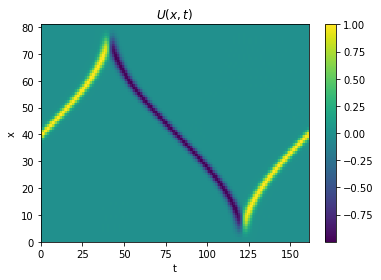

In [ ]:
# Adaptation of program 18 in Trefethen

f = lambda x: numpy.exp(x) * numpy.sin(5.0 * x)  
# Fungsi f(x)

f_prime = lambda x: numpy.exp(x) * (numpy.sin(5.0 * x) + 5.0 * numpy.cos(5.0 * x))  
# Turunan analitik f'(x)

x_fine = numpy.arange(-1, 1, 0.01)  
# Grid halus untuk plot referensi

fig, axes = plt.subplots(2, 2)  
# Membuat subplot 2x2

fig.set_figwidth(fig.get_figwidth() * 2)  
# Memperlebar figure

fig.set_figheight(fig.get_figheight() * 2)  
# Mempertinggi figure

for (i, N) in enumerate((10, 20)):  
    # Loop untuk dua nilai N

    x = numpy.cos(numpy.pi * numpy.arange(N+1) / N)  
    # Titik Chebyshev

    axes[i, 0].plot(x, f(x), '.', markersize=14)  
    # Plot nilai fungsi pada titik Chebyshev

    axes[i, 0].plot(x_fine, f(x_fine))  
    # Plot fungsi asli pada grid halus

    axes[i, 0].grid(True)  

    axes[i, 0].set_title("$f(x)$, N = %s" % N)  
    
    error = chebfft(f(x)) - f_prime(x)  
    # Hitung error antara turunan numerik (chebfft) dan analitik

    axes[i, 1].plot(x, error, '.', markersize=14)  
    # Plot error (titik)

    axes[i, 1].plot(x, error)  
    # Plot error (garis)

    axes[i, 1].grid(True)  

    axes[i, 1].set_title("Error in $f'(x)$, N = %s" % N)  

## Kuadratur Spektral

Salah satu konsekuensi paling kuat dari sebagian besar yang telah kita lakukan sebenarnya terlihat melalui integral. Karena integral adalah operasi yang menghaluskan (smoothing), mungkin tidak terlalu mengejutkan bahwa hal ini memang terjadi.

Jika kita ingin mengaproksimasi integral
$$
    I = \int^1_{-1} f(x) dx
$$
salah satu cara yang dapat kita lakukan adalah mencari interpolan polinomial dari $f(x)$ dan mengintegrasikannya sebagai gantinya. Ini dikenal sebagai kuadratur Clenshaw-Curtis dan merupakan orde optimal pada himpunan tetap node Chebyshev.

Kita akan mengikuti proses yang telah kita gunakan untuk menghubungkan FFT dengan deret Chebyshev sehingga kita peroleh
$$\begin{aligned}
    \int^1_{-1} p(x) dx &= \int^1_{-1} p(z) \frac{dx}{dz} dz \\
    &= \frac{1}{4} \sum^N_{n=0} a_n \int^1_{-1} (z^n + z^{-n}) (1 - z^{-2}) dz\\
    &= \frac{1}{4} \sum^N_{n=0} a_n \int^1_{-1} (z^n - z^{n - 2} + z^{-n} - z^{-n - 2}) dz \\
    &= \frac{1}{4} \sum^N_{n=0} a_n \left(\left. \frac{z^{n+1} + z^{-n-1}}{n+1} \right |^1_{-1} - \left. \frac{z^{n-1} + z^{-n+1}}{n-1} \right |^1_{-1} \right) \\
    &= \sum^N_{n=0, n \text{ genap}} a_n \left(\frac{1}{n+1} - \frac{1}{n - 1}\right) \\
    &= \sum^N_{n=0, n \text{ genap}} \frac{2a_n}{1 - n^2}.
\end{aligned}$$
Dengan ini, kita menggunakan FFT untuk menentukan $a_n$ seperti yang telah dijelaskan sebelumnya.

In [ ]:
def cheb_diff(N):
    """Compute the inverse differentiation matrix and return the x locations."""
    
    D, x = cheb(N)  
    # Mengambil differentiation matrix D dan titik Chebyshev x

    D_inv = numpy.linalg.inv(D[:-1, :-1])  
    # Mengambil submatrix (tanpa titik terakhir/boundary)
    # lalu menghitung invers dari matriks turunan tersebut

    x = x[:-1]  
    # Menghapus titik terakhir agar sesuai dengan ukuran D_inv

    return D_inv, x  
    # Mengembalikan invers matriks turunan dan titik Chebyshev

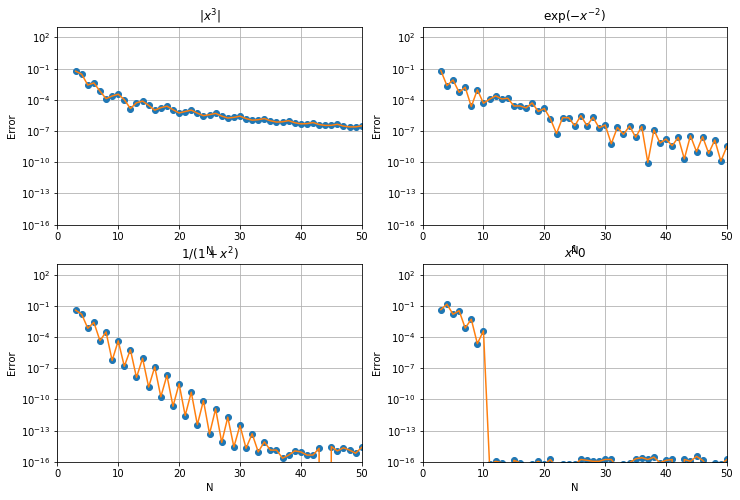

In [ ]:
# Compare errors more carefully (program 30 in Trefethen)
# Example directly uses Chebyshev differentiation matrix

import scipy.special  
# Untuk fungsi khusus seperti erf

N_max = 50  
# Nilai maksimum N

error = numpy.zeros((4, N_max - 2))  
# Menyimpan error untuk 4 jenis fungsi

N_range = numpy.arange(3, N_max + 1)  
# Range nilai N dari 3 sampai 50

for (i, N) in enumerate(N_range):  
    # Loop untuk setiap N

    D_inv, x = cheb_diff(N)  
    # Ambil invers differentiation matrix dan titik Chebyshev

    # =========================
    # 1. Fungsi |x|^3
    # =========================
    f = numpy.abs(x)**3  
    # Fungsi

    f_int = 0.5  
    # Nilai integral eksak

    error[0, i] = numpy.abs(numpy.dot(D_inv[0, :].transpose(), f) - f_int)  
    # Error integral numerik vs eksak

    # =========================
    # 2. Fungsi C-infinity
    # =========================
    f = numpy.exp(-x**(-2))  

    f_int = 2.0 * (numpy.exp(-1) + numpy.sqrt(numpy.pi) * (scipy.special.erf(1) - 1))  
    # Nilai integral eksak (melibatkan erf)

    error[1, i] = numpy.abs(numpy.dot(D_inv[0, :].transpose(), f) - f_int)  

    # =========================
    # 3. Fungsi analitik
    # =========================
    f = 1.0 / (1.0 + x**2)  

    f_int = numpy.pi / 2.0  

    error[2, i] = numpy.abs(numpy.dot(D_inv[0, :].transpose(), f) - f_int)  

    # =========================
    # 4. Polinomial
    # =========================
    f = x**10  

    f_int = 2.0 / 11.0  

    error[3, i] = numpy.abs(numpy.dot(D_inv[0, :].transpose(), f) - f_int)  

# =========================
# PLOT ERROR
# =========================

fig = plt.figure()  

fig.set_figwidth(fig.get_figwidth() * 2)  
# Memperlebar plot

fig.set_figheight(fig.get_figheight() * 2)  
# Mempertinggi plot

titles = ['$|x^3|$', '$\\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']  
# Judul tiap subplot

for (i, title) in enumerate(titles):  
    # Loop tiap subplot

    axes = fig.add_subplot(2, 2, i + 1)  

    axes.semilogy(N_range, error[i, :], '.', markersize=12)  
    # Plot titik error (log scale)

    axes.semilogy(N_range, error[i, :])  
    # Plot garis error

    axes.set_xlim((0, N_max))  

    axes.set_ylim((1e-16, 1e3))  
    # Rentang error

    axes.grid(True)  

    axes.set_xlabel("N")  

    axes.set_ylabel("Error")  

    axes.set_title(title)  

In [ ]:
def clencurt(N):
    raise NotImplementedError("This does not work yet :(")  
    # Fungsi belum diimplementasikan (akan langsung error jika dipanggil)

    theta = numpy.pi * numpy.arange(N + 1) / N  
    # Membuat grid sudut θ dari 0 sampai π

    x = numpy.cos(theta)  
    # Mengubah ke titik Chebyshev (x = cos(θ))

    w = numpy.zeros(N + 1)  
    # Inisialisasi bobot integrasi

    # ii = numpy.arange(1, N)  
    # Baris ini dikomentari (tidak digunakan)

    v = numpy.ones(N - 1)  
    # Inisialisasi nilai tengah untuk bobot

    if numpy.mod(N, 2) == 0:  
        # Jika N genap

        w[0] = 1.0 / (N**2 - 1.0)  
        # Bobot di ujung kiri

        w[-1] = w[0]  
        # Bobot di ujung kanan sama

        for k in range(N / 2):  
            # Loop hingga N/2

            v -= 2.0 * numpy.cos(2.0 * k * theta[1:-1]) / (4.0 * k**2 - 1.0)  
            # Update nilai v berdasarkan rumus Clenshaw-Curtis

        v -= numpy.cos(N * theta[1:-1]) / (N**2 - 1.0)  
        # Koreksi tambahan untuk kasus genap

    else:  
        # Jika N ganjil

        w[0] = 1.0 / N**2  
        # Bobot ujung kiri

        w[-1] = w[0]  
        # Bobot ujung kanan

        for k in range((N - 1) / 2 + 1):  
            # Loop hingga (N-1)/2

            v -= 2.0 * numpy.cos(2.0 * k * theta[1:-1]) / (4.0 * k**2 - 1.0)  
            # Update v

    w[1:-1] = 2.0 * v / N  
    # Menghitung bobot untuk titik interior

    return w, x  
    # Mengembalikan bobot integrasi dan titik Chebyshev

In [ ]:
# Compare errors more carefully (program 30 in Trefethen)
# Example using Clenshaw-Curtis quadrature weights

import scipy.special  
# Untuk fungsi khusus seperti erf

N_max = 50  
# Nilai maksimum N

error = numpy.zeros((4, N_max - 2))  
# Menyimpan error untuk 4 jenis fungsi

N_range = numpy.arange(3, N_max + 1)  
# Range nilai N

for (i, N) in enumerate(N_range):  
    # Loop untuk setiap N

    w, x = clencurt(N)  
    # Ambil bobot integrasi (w) dan titik Chebyshev (x)

    # =========================
    # 1. Fungsi |x|^3
    # =========================
    f = numpy.abs(x)**3  
    # Fungsi

    f_int = 0.5  
    # Nilai integral eksak

    error[0, i] = numpy.abs(numpy.dot(w, f) - f_int)  
    # Error integral numerik vs eksak

    # =========================
    # 2. Fungsi C-infinity
    # =========================
    f = numpy.exp(-x**(-2))  

    f_int = 2.0 * (numpy.exp(-1) + numpy.sqrt(numpy.pi) * (scipy.special.erf(1) - 1))  
    # Nilai integral eksak

    error[1, i] = numpy.abs(numpy.dot(w, f) - f_int)  

    # =========================
    # 3. Fungsi analitik
    # =========================
    f = 1.0 / (1.0 + x**2)  

    f_int = numpy.pi / 2.0  

    error[2, i] = numpy.abs(numpy.dot(w, f) - f_int)  

    # =========================
    # 4. Polinomial
    # =========================
    f = x**10  

    f_int = 2.0 / 11.0  

    error[3, i] = numpy.abs(numpy.dot(w, f) - f_int)  

# =========================
# PLOT ERROR
# =========================

fig = plt.figure()  

fig.set_figwidth(fig.get_figwidth() * 2)  
# Memperlebar plot

fig.set_figheight(fig.get_figheight() * 2)  
# Mempertinggi plot

titles = ['$|x^3|$', '$\\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']  
# Judul subplot

for (i, title) in enumerate(titles):  
    # Loop tiap subplot

    axes = fig.add_subplot(2, 2, i + 1)  

    axes.semilogy(N_range, error[i, :], '.', markersize=12)  
    # Plot titik error (log scale)

    axes.semilogy(N_range, error[i, :])  
    # Plot garis error

    axes.set_xlim((0, N_max))  

    axes.set_ylim((1e-16, 1e3))  
    # Rentang error

    axes.grid(True)  

    axes.set_xlabel("N")  

    axes.set_ylabel("Error")  

    axes.set_title(title)  

NotImplementedError: This does not work yet :(

In [ ]:
def gauss(N):
    beta = 0.5 / numpy.sqrt(1.0 - (2.0 * numpy.arange(1, N))**(-2))  
    # Koefisien beta untuk matriks Jacobi (berkaitan dengan polinomial Legendre)

    T = numpy.diag(beta, 1) + numpy.diag(beta, -1)  
    # Membentuk matriks tridiagonal simetris (Jacobi matrix)

    x, V = numpy.linalg.eig(T)  
    # Menghitung eigenvalue (x) dan eigenvector (V)
    # Eigenvalue → titik Gauss (nodes)
    # Eigenvector → digunakan untuk bobot

    i = numpy.argsort(x)  
    # Mengurutkan indeks berdasarkan nilai x

    x = x[i]  
    # Mengurutkan titik Gauss

    w = 2.0 * V[0, i]**2  
    # Menghitung bobot Gauss (berdasarkan elemen pertama eigenvector)

    return w, x  
    # Mengembalikan bobot dan titik Gauss

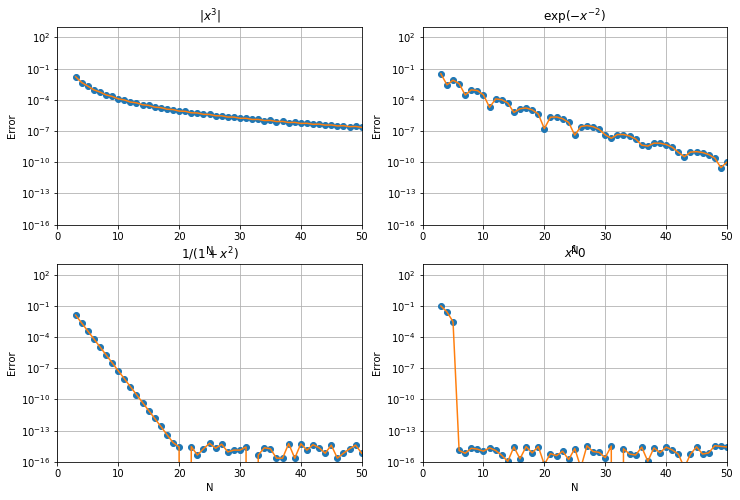

In [ ]:
# Compare errors more carefully (program 30 in Trefethen)
# Example using Gaussian quadrature (using Legendre points)

import scipy.special  
# Untuk fungsi khusus seperti erf

N_max = 50  
# Nilai maksimum N

error = numpy.zeros((4, N_max - 2))  
# Menyimpan error untuk 4 jenis fungsi

N_range = numpy.arange(3, N_max + 1)  
# Range nilai N

for (i, N) in enumerate(N_range):  
    # Loop untuk setiap N

    w, x = gauss(N)  
    # Ambil bobot (w) dan titik Gauss-Legendre (x)

    # =========================
    # 1. Fungsi |x|^3
    # =========================
    f = numpy.abs(x)**3  
    # Fungsi

    f_int = 0.5  
    # Nilai integral eksak

    error[0, i] = numpy.abs(numpy.dot(w, f) - f_int)  
    # Error integral numerik vs eksak

    # =========================
    # 2. Fungsi C-infinity
    # =========================
    f = numpy.exp(-x**(-2))  

    f_int = 2.0 * (numpy.exp(-1) + numpy.sqrt(numpy.pi) * (scipy.special.erf(1) - 1))  
    # Nilai integral eksak

    error[1, i] = numpy.abs(numpy.dot(w, f) - f_int)  

    # =========================
    # 3. Fungsi analitik
    # =========================
    f = 1.0 / (1.0 + x**2)  

    f_int = numpy.pi / 2.0  

    error[2, i] = numpy.abs(numpy.dot(w, f) - f_int)  

    # =========================
    # 4. Polinomial
    # =========================
    f = x**10  

    f_int = 2.0 / 11.0  

    error[3, i] = numpy.abs(numpy.dot(w, f) - f_int)  

# =========================
# PLOT ERROR
# =========================

fig = plt.figure()  

fig.set_figwidth(fig.get_figwidth() * 2)  
# Memperlebar plot

fig.set_figheight(fig.get_figheight() * 2)  
# Mempertinggi plot

titles = ['$|x^3|$', '$\\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']  
# Judul tiap subplot

for (i, title) in enumerate(titles):  
    # Loop tiap subplot

    axes = fig.add_subplot(2, 2, i + 1)  

    axes.semilogy(N_range, error[i, :], '.', markersize=12)  
    # Plot titik error (log scale)

    axes.semilogy(N_range, error[i, :])  
    # Plot garis error

    axes.set_xlim((0, N_max))  

    axes.set_ylim((1e-16, 1e3))  
    # Rentang error

    axes.grid(True)  

    axes.set_xlabel("N")  

    axes.set_ylabel("Error")  

    axes.set_title(title)  